#### Libraries

In [61]:
import pandas as pd
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.express as px
import requests
import time
import xml.etree.ElementTree as ET
import numpy as np
from sklearn.preprocessing import MinMaxScaler

## Data

#### PPI

In [62]:
protein_interaction = pd.read_csv('Data/Protein-protein interaction data/9606.protein.links.v12.0.txt', sep= ' ')
protein_interaction_full = pd.read_csv('Data/Protein-protein interaction data/9606.protein.links.full.v12.0.txt', sep= ' ')
protein_interaction_detailed = pd.read_csv('Data/Protein-protein interaction data/9606.protein.links.detailed.v12.0.txt', sep= ' ')
### convert proteins to their true names
protein_info = pd.read_csv('Data/Protein-protein interaction data/9606.protein.info.v12.0.txt', on_bad_lines='skip', sep='\t')
protein_aliases= pd.read_csv('Data/Protein-protein interaction data/9606.protein.aliases.v12.0.txt', on_bad_lines='skip', sep='\t')

In [63]:
### convert proteins to their true names
protein_info = pd.read_csv('Data/Protein-protein interaction data/9606.protein.info.v12.0.txt', on_bad_lines='skip', sep='\t')
protein_aliases= pd.read_csv('Data/Protein-protein interaction data/9606.protein.aliases.v12.0.txt', on_bad_lines='skip', sep='\t')

# Method 1: Using the to_dict() method with 'index' as orient
protein_info_translate_name_dict = protein_info.set_index('#string_protein_id')['preferred_name'].to_dict()
protein_alias_translate_name_dict = protein_aliases.set_index('#string_protein_id')['alias'].to_dict()
#print(protein_info_translate_name_dict)

### Protein1
protein1_name = []
for prot_id in tqdm(protein_interaction['protein1']):
    if prot_id in protein_info_translate_name_dict:
        protein1_name.append(protein_info_translate_name_dict[prot_id])
    elif prot_id in protein_alias_translate_name_dict:
        protein1_name.append(protein_alias_translate_name_dict[prot_id])
    else:
        protein1_name.append('')

### Protein 2
protein2_name = []
for prot_id in tqdm(protein_interaction['protein2']):
    if prot_id in protein_info_translate_name_dict:
        protein2_name.append(protein_info_translate_name_dict[prot_id])
    elif prot_id in protein_alias_translate_name_dict:
        protein2_name.append(protein_alias_translate_name_dict[prot_id])
    else:
        protein2_name.append('')

protein_interaction['Translated_protein_1'] = protein1_name
protein_interaction['Translated_protein_2'] = protein2_name

# Create a set of all (protein1, protein2) pairs
ppi_pairs = set(zip(protein_interaction['Translated_protein_1'], protein_interaction['Translated_protein_2']))
# Check for missing reverse pairs
missing_reverse = []
for a, b in ppi_pairs:
    if (b, a) not in ppi_pairs:
        missing_reverse.append((a, b))

print(f"Number of pairs missing their reverse: {len(missing_reverse)}")
if missing_reverse:
    print("Examples:", missing_reverse[:10])
else:
    print("All pairs have their reverse present.")

100%|██████████| 13715404/13715404 [00:02<00:00, 5319858.69it/s]


Number of pairs missing their reverse: 0
All pairs have their reverse present.


In [64]:
protein_interaction

,protein1,protein2,combined_score,Translated_protein_1,Translated_protein_2
0,9606.ENSP00000000233,9606.ENSP00000356607,173,ARF5,RALGPS2
1,9606.ENSP00000000233,9606.ENSP00000427567,154,ARF5,FHDC1
2,9606.ENSP00000000233,9606.ENSP00000253413,151,ARF5,ATP6V1E1
3,9606.ENSP00000000233,9606.ENSP00000493357,471,ARF5,CYTH2
4,9606.ENSP00000000233,9606.ENSP00000324127,201,ARF5,PSD3
...,...,...,...,...,...
13715399,9606.ENSP00000501317,9606.ENSP00000475489,195,RFX7,MPHOSPH9
13715400,9606.ENSP00000501317,9606.ENSP00000370447,158,RFX7,VCX
13715401,9606.ENSP00000501317,9606.ENSP00000312272,226,RFX7,YPEL2
13715402,9606.ENSP00000501317,9606.ENSP00000402092,169,RFX7,SAMD3


#### Drug Bank

In [65]:
# import xml.etree.ElementTree as ET

# # Load XML
# drugbank_xml = 'Data/DGIDB/drug_bank.xml'
# tree = ET.parse(drugbank_xml)
# root = tree.getroot()

# # Namespace
# ns = {'db': 'http://www.drugbank.ca'}

# Helper to clean tag names
def clean_tag(tag):
    return tag.split('}')[-1] if '}' in tag else tag

# Recursive function to print structure
def print_structure(elem, level=0):
    indent = '  ' * level
    print(f"{indent}- {clean_tag(elem.tag)}")
    for child in elem:
        print_structure(child, level + 1)

# # Get first drug
# first_drug = root.find('db:drug', ns)

# print("🌿 Structure of First Drug Entry:")
# print_structure(first_drug)
# print("\n🌳 Structure of First 3 Drug Entries:")
# drugs = root.findall('db:drug', ns)

# for i, drug in enumerate(drugs[:3]):
#     print(f"\n🔬 Drug {i+1}:")
#     print_structure(drug)


In [66]:
def structure_drug_bank_data(drug_bank_file = 'Data/DGIDB/drug_bank.xml'):
    """
    Function to structure the drug bank data from the XML file.
    :param drug_bank_file: Path to the drug bank XML file.
    :return: DataFrame containing structured drug bank data.
    """
    ### FYI the .find command only finds the first instance of a tag, 
    ### while .findall retrieves all instances of the specified tag within the current element.

    tree = ET.parse(drug_bank_file)
    root = tree.getroot()

    # DrugBank uses a specific namespace
    ns = {'db': 'http://www.drugbank.ca'}
    ### extract all drug elements
    drugs = root.findall('db:drug', ns)
    print(f"Found {len(drugs)} drugs in the DrugBank XML.")
    # Extract drug-gene interactions
    interactions = []
    # The interactions list will store dictionaries with 'drug' and 'gene' keys.
    for drug in root.findall('db:drug', ns): # root.findall('db:drug', ns): Finds all <drug> elements using the namespace.
        drug_name  = drug.find('db:name', ns).text  # drug.find('db:name', ns): Gets the drug's name.
        # print(drug_name)
        for target in drug.findall('db:targets/db:target', ns):  # drug.findall('db:targets/db:target', ns): Finds all <target> elements within <targets>.
            # print(target.tag)
            gene_description = target.find('db:name', ns)  # target.find('db:name', ns): Extracts the gene name for each target.
            poly = target.find('db:polypeptide', ns)  # target.find('db:polypeptide', ns): Extracts the polypeptide information.
            action = target.find('db:actions/db:action', ns) # target.find('db:actions/db:action', ns): Extracts the action of the drug on the target.
            if poly is not None:
                poly_name = poly.find('db:name', ns)
                gene_name = poly.find('db:gene-name', ns)
                specific_function = poly.find('db:specific-function', ns)
                interactions.append({
                    'drug': drug_name,
                    'polypeptide': poly_name.text if poly_name is not None else None,
                    'gene': gene_name.text if gene_name is not None else None,
                    'gene_description': gene_description.text if gene_description is not None else None,
                    'action': action.text if action is not None else None,
                    'specific_function': specific_function.text if specific_function is not None else None
                })
            ############# if polypeptide is not present, we still want to add the drug and gene information
            ############# this is because some drugs may not have a polypeptide associated with them
            ############# but we still want to capture the drug and gene information
            ############# this is common in the DrugBank database, where some drugs target genes directly
            ############# and do not have a polypeptide associated with them

            else:
                gene_name = None
                specific_function = None
                poly_name = None
                action = None
                gene_description = None
                resource = None
                identifier = None
  
                interactions.append({
                        'drug': drug_name,
                        'polypeptide': poly_name.text if poly_name is not None else None,
                        'gene': gene_name.text if gene_name is not None else None,
                        'gene_description': gene_description.text if gene_description is not None else None,
                        'action': action.text if action is not None else None,
                        'specific_function': specific_function.text if specific_function is not None else None
                    })
        
    # Convert to DataFrame
    # Converts the list of dictionaries into a pandas DataFrame, which is easier to analyze, filter, and export.
    df = pd.DataFrame(interactions)

    return df

In [67]:
Drug_bank = structure_drug_bank_data('Data/DGIDB/drug_bank.xml')

Found 17430 drugs in the DrugBank XML.


In [68]:
print(f"{len(set(Drug_bank['drug']))} unique drugs found in DrugBank.")
print(f"{len(set(Drug_bank['gene']))} unique genes found in DrugBank.")
print(f"{len(set(tuple(Drug_bank['drug'] + Drug_bank['gene'])))} unique drug-gene pairs found in DrugBank.")
print(f"{len(Drug_bank)} size of DrugBank interactions found in DrugBank.")

9368 unique drugs found in DrugBank.
4187 unique genes found in DrugBank.
21714 unique drug-gene pairs found in DrugBank.
23136 size of DrugBank interactions found in DrugBank.


#### CNV Results

In [69]:
hpv_positive_amplification_gene_df = pd.read_csv('Results/CNV results/HPV positive amplification genes.csv')
hpv_positive_top_amplification_genes = list(hpv_positive_amplification_gene_df['gene_name'].values)

hpv_positive_deletion_gene_df = pd.read_csv('Results/CNV results/HPV positive deletion genes.csv')
hpv_positive_top_deletion_genes = list(hpv_positive_deletion_gene_df['gene_name'].values)

hpv_negative_amplification_gene_df = pd.read_csv('Results/CNV results/HPV negative amplification genes.csv')
hpv_negative_top_amplification_genes = list(hpv_negative_amplification_gene_df['gene_name'].values)

hpv_negative_deletion_gene_df = pd.read_csv('Results/CNV results/HPV negative deletion genes.csv')
hpv_negative_top_deletion_genes = list(hpv_negative_deletion_gene_df['gene_name'].values)

In [70]:
hpv_positive_amplification_gene_df

,gene,gene_name,Sample_size,amplification_count,Amplification_sum (i.e. total log2(amplification CNV) across samples),Amplification_sum_prevalence,frequency_percentage,gistic_score,p_value,q_value,significant,empirical_p_value,empirical_q_value,empirical_significant
0,ENSG00000252257.1,RN7SKP265,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
1,ENSG00000266317.2,RN7SL703P,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
2,ENSG00000199839.1,RNA5SP150,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
3,ENSG00000242512.9,LINC01206,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
4,ENSG00000240478.1,AC012081.1,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60618,ENSG00000236457.1,AC090617.1,221,0,32.509775,0.147103,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False
60619,ENSG00000235368.1,SAPCD2P2,221,0,36.019550,0.162984,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False
60620,ENSG00000152128.13,TMEM163,221,0,35.604513,0.161106,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False
60621,ENSG00000272807.1,AC007038.1,221,0,27.434588,0.124138,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False


## Identify top genes

In [71]:
def plot_score_distribution(df):
    """
    Function to plot the distribution of scores in a DataFrame.
    To allow for visual determination of the best cutoff for each score.
    The scores analyzed are GISTIC2.0, frequency_percentage, gistic_score, p-value, and q-value.
    """

    # Get the df variable name to get the title of the plot
    title = f"Distribution of Scores with mean and 95th Percentile"

    scores = ['frequency_percentage', 'gistic_score', 'q_value', 'empirical_q_value']
    #df = df[(df['frequency_percentage'] != 0) & (df['gistic_score'] != 0)]
    ### want larger plots to see all 100 bins
    plt.figure(figsize=(15, 10))
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.subplots_adjust(hspace=0.4, wspace=0.4)
    for i, score in enumerate(scores):
        plt.subplot(3, 2, i + 1)
        ### plot the histogram with 100 bins
        ### set alpha to 0.7 for better visibility
        ### set color to blue and edgecolor to black for better visibility
        ### set yscale to log for better visibility of the distribution
        plt.hist(df[score], bins=100, alpha=0.7, color='blue', edgecolor='black')
        if score == 'empirical_q_value' or score == 'q_value':
            plt.axvline(.05, color='red', linestyle='dashed', linewidth=1, label = 'Significance Threshold: 0.05')
            #plt.axvline(df[score].quantile(0.05), color='green', linestyle='dashed', linewidth=1, label = f'95th Percentile of {score}: {df[score].quantile(0.05):.4f}')
        else:
            plt.axvline(df[score].mean(), color='red', linestyle='dashed', linewidth=1, label = f'Mean of {score}: {df[score].mean():.4f}')
            plt.axvline(df[score].quantile(0.95), color='green', linestyle='dashed', linewidth=1, label = f'95th Percentile of {score}: {df[score].quantile(0.95):.4f}')
        plt.title(f'Distribution of {score}')
        plt.xlabel(score)
        plt.ylabel('Frequency')
        plt.legend()
        plt.yscale('log')
        plt.grid(axis='y', alpha=0.75)    
    plt.show()

In [ ]:
def plot_score_distribution_with_cutoff(df, cutoff):
    """
    Function to plot the distribution of scores in a DataFrame with a cutoff line.
    The scores analyzed are GISTIC2.0, frequency_percentage, gistic_score, p-value, and q-value.
    These scores are a dictionary with the cutoff values for each score. keys are the score names and values are the cutoff values.
    """
    # Get the df variable name to get the title of the plot
    # df_name = [name for name in globals() if globals()[name] is df][0]
    # print(df_name)
    title = f"Distribution of Scores  with Cutoffs"
    # Remove any existing figure to avoid overlapping titles in Jupyter
    plt.close('all')
    scores = ['frequency_percentage', 'gistic_score', 'q_value', 'empirical_q_value']
    plt.figure(figsize=(15, 10))
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.subplots_adjust(top=0.9)  # Adjust the top to make space for the title
    for i, score in enumerate(scores):
        if score not in cutoff:
            continue
        plt.subplot(3, 2, i + 1)
        plt.hist(df[score], bins=100, alpha=0.7, color='blue', edgecolor='black')
        if score == 'empirical_q_value' or score == 'q_value':
            plt.axvline(.05, color='red', linestyle='dashed', linewidth=1, label = 'Significance Threshold: 0.05')
            #plt.axvline(cutoff[score], color='red', linestyle='--', label=f'Cutoff: {cutoff[score]}')
            plt.axvline(df[score].quantile(0.05), color='green', linestyle='dashed', linewidth=1, label = f'95th Percentile of {score}: {df[score].quantile(0.05):.4f}')
        elif df[score].mean() < 0:
            plt.axvline(x=cutoff[score], color='red', linestyle='--', label=f'Cutoff: {cutoff[score]}')
            plt.axvline(df[score].quantile(.95), color='green', linestyle='dashed', linewidth=1, label=f'5th Percentile of {score}: {df[score].quantile(.95):.4f}')
        else:
            plt.axvline(x=cutoff[score], color='red', linestyle='--', label=f'Cutoff: {cutoff[score]}')
            plt.axvline(df[score].quantile(.95), color='green', linestyle='dashed', linewidth=1, label=f'95th Percentile of {score}: {df[score].quantile(.95):.4f}')
        plt.title(f'Distribution of {score}')
        plt.xlabel(score)
        plt.ylabel('Frequency')
        plt.legend()
        plt.yscale('log')
        plt.grid(axis='y', alpha=0.75)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### HPV+

#### Amp

In [73]:
hpv_positive_amplification_gene_df

,gene,gene_name,Sample_size,amplification_count,Amplification_sum (i.e. total log2(amplification CNV) across samples),Amplification_sum_prevalence,frequency_percentage,gistic_score,p_value,q_value,significant,empirical_p_value,empirical_q_value,empirical_significant
0,ENSG00000252257.1,RN7SKP265,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
1,ENSG00000266317.2,RN7SL703P,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
2,ENSG00000199839.1,RNA5SP150,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
3,ENSG00000242512.9,LINC01206,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
4,ENSG00000240478.1,AC012081.1,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60618,ENSG00000236457.1,AC090617.1,221,0,32.509775,0.147103,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False
60619,ENSG00000235368.1,SAPCD2P2,221,0,36.019550,0.162984,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False
60620,ENSG00000152128.13,TMEM163,221,0,35.604513,0.161106,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False
60621,ENSG00000272807.1,AC007038.1,221,0,27.434588,0.124138,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False


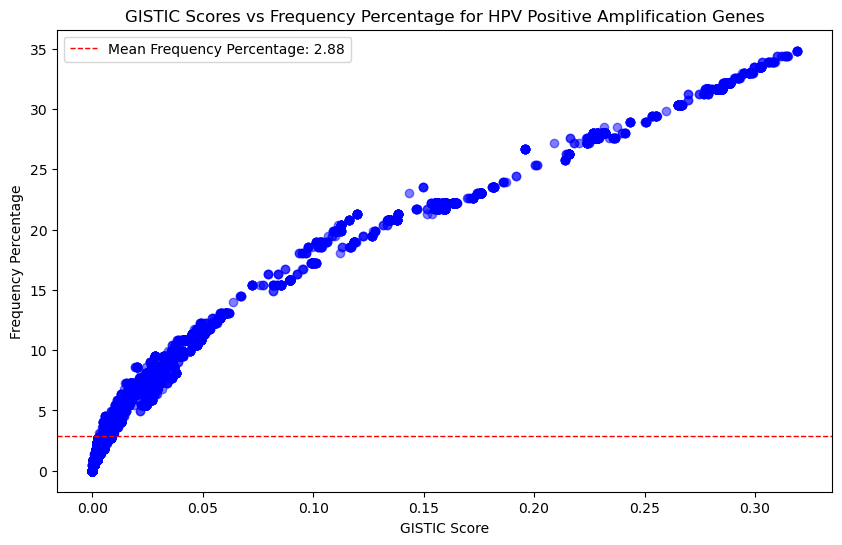

In [74]:
### plot distribution of gistic scores vs frequency percatage
plt.figure(figsize=(10, 6))
plt.scatter(hpv_positive_amplification_gene_df['gistic_score'], hpv_positive_amplification_gene_df['frequency_percentage'], alpha=0.5, color='blue')
plt.title('GISTIC Scores vs Frequency Percentage for HPV Positive Amplification Genes')
plt.xlabel('GISTIC Score')
plt.ylabel('Frequency Percentage')
plt.axhline(y=hpv_positive_amplification_gene_df['frequency_percentage'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean Frequency Percentage: {hpv_positive_amplification_gene_df["frequency_percentage"].mean():.2f}')
plt.legend()
plt.show()

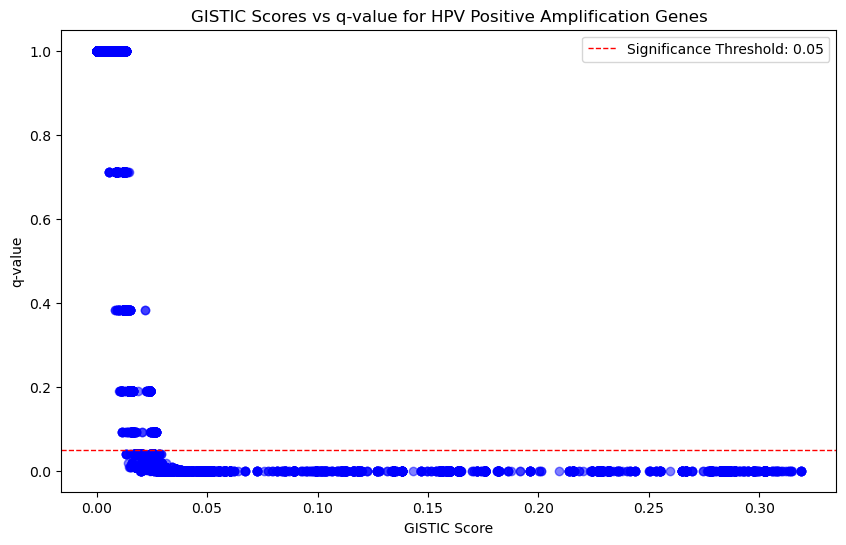

In [75]:
## plot gistic score vs q value
plt.figure(figsize=(10, 6))
plt.scatter(hpv_positive_amplification_gene_df['gistic_score'], hpv_positive_amplification_gene_df['q_value'], alpha=0.5, color='blue')
plt.title('GISTIC Scores vs q-value for HPV Positive Amplification Genes')
plt.xlabel('GISTIC Score')
plt.ylabel('q-value')
plt.axhline(y=0.05, color='red', linestyle='dashed', linewidth=1, label='Significance Threshold: 0.05')
plt.legend()
plt.show()

In [76]:
hpv_positive_amplification_gene_df

,gene,gene_name,Sample_size,amplification_count,Amplification_sum (i.e. total log2(amplification CNV) across samples),Amplification_sum_prevalence,frequency_percentage,gistic_score,p_value,q_value,significant,empirical_p_value,empirical_q_value,empirical_significant
0,ENSG00000252257.1,RN7SKP265,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
1,ENSG00000266317.2,RN7SL703P,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
2,ENSG00000199839.1,RNA5SP150,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
3,ENSG00000242512.9,LINC01206,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
4,ENSG00000240478.1,AC012081.1,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60618,ENSG00000236457.1,AC090617.1,221,0,32.509775,0.147103,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False
60619,ENSG00000235368.1,SAPCD2P2,221,0,36.019550,0.162984,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False
60620,ENSG00000152128.13,TMEM163,221,0,35.604513,0.161106,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False
60621,ENSG00000272807.1,AC007038.1,221,0,27.434588,0.124138,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.00000,False


In [77]:
## using plotly plot the distribution of gistic SCORES by gene name
def plot_gistic_distribution(df, title):
    ### plotly will add dots for significant incr
    import plotly.express as px
    fig = px.box(df, x='gene_name', y='gistic_score', title=title)
    ### add horizontal line cut off at .01
    fig.add_hline(y=0.29, line_dash="dash", line_color="red", annotation_text="Cutoff: 0.01", annotation_position="top left")
    fig.show()

In [78]:
plot_gistic_distribution(hpv_positive_amplification_gene_df, "HPV Positive Amplification Genes GISTIC2.0 Score Distribution")

In [79]:
### plot Amplification_sum (i.e. total log2(amplification CNV) across samples) of hpv_positive_amplification_gene_df
def plot_amplification_sum(df, title):
    """
    Function to plot the amplification sum of a DataFrame.
    The amplification sum is the total log2(amplification CNV) across samples.
    """
    plt.figure(figsize=(10, 6))
    plt.bar(df['gene_name'], df['Amplification_sum (i.e. total log2(amplification CNV) across samples)'], color='blue', edgecolor='black')
    plt.axhline(y=0.01, color='red', linestyle='dashed', linewidth=1, label='Cutoff: 0.01')
    plt.title(title)
    plt.xlabel('Gene Name')
    plt.ylabel('Amplification Sum')
    plt.xticks(rotation=90)
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

/var/folders/5p/swntgnbj3fbfxkx02kt3fq980000gn/T/ipykernel_210/1781921066.py:8: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



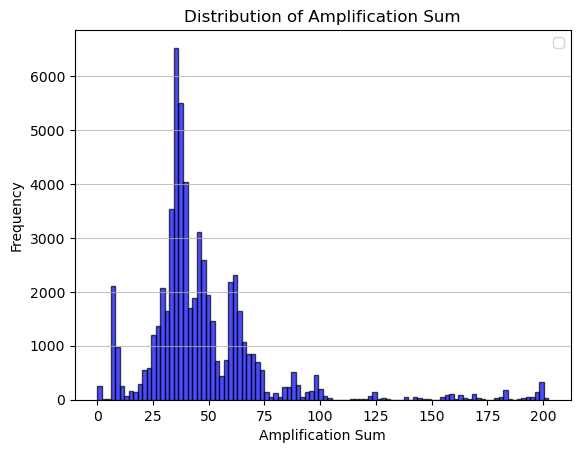

In [80]:
### plot histogram of Amplification_sum (i.e. total log2(amplification CNV) across samples) in hpv_positive_amplification_gene_df
plt.Figure(figsize=(10, 6))
plt.hist(hpv_positive_amplification_gene_df['Amplification_sum (i.e. total log2(amplification CNV) across samples)'], bins=100, alpha=0.7, color='blue', edgecolor='black')
#plt.axvline(0.01, color='red', linestyle='dashed', linewidth=1, label='Cutoff: 0.01')
plt.title('Distribution of Amplification Sum')
plt.xlabel('Amplification Sum')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

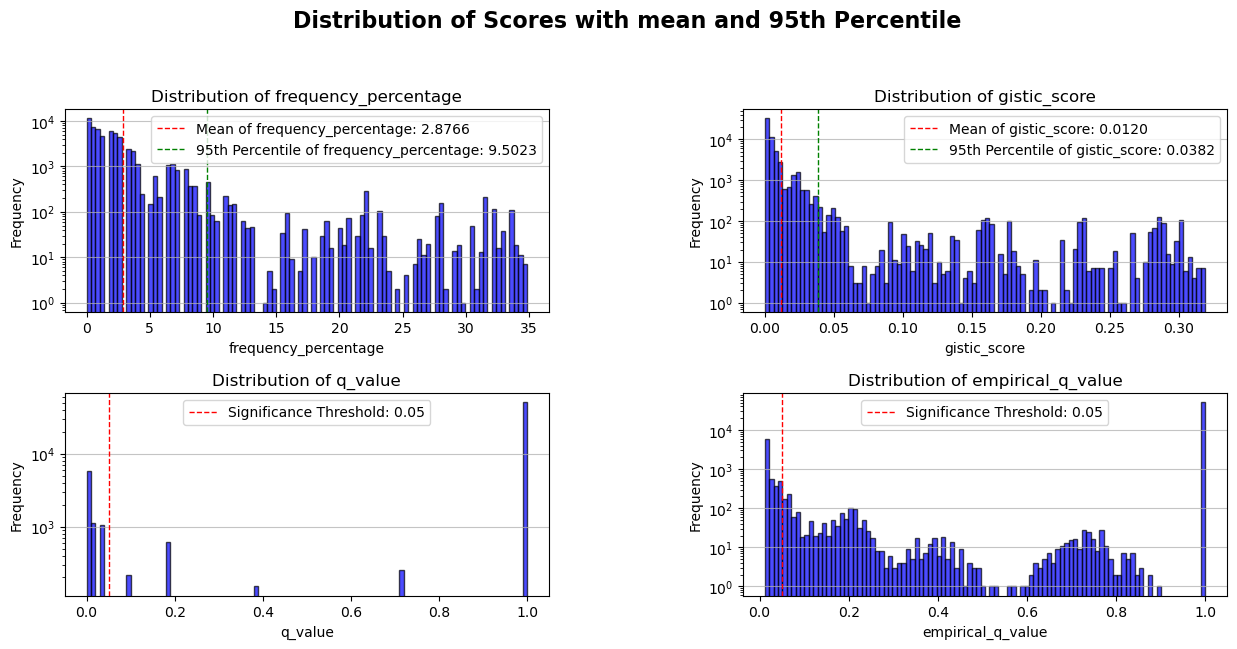

In [81]:
plot_score_distribution(hpv_positive_amplification_gene_df)

In [82]:
### decided cut offs
cutoffs = {
    'frequency_percentage': 30,
    'gistic_score': 0.296,
    'empirical_q_value': 0.05,
    'q_value': .05
}


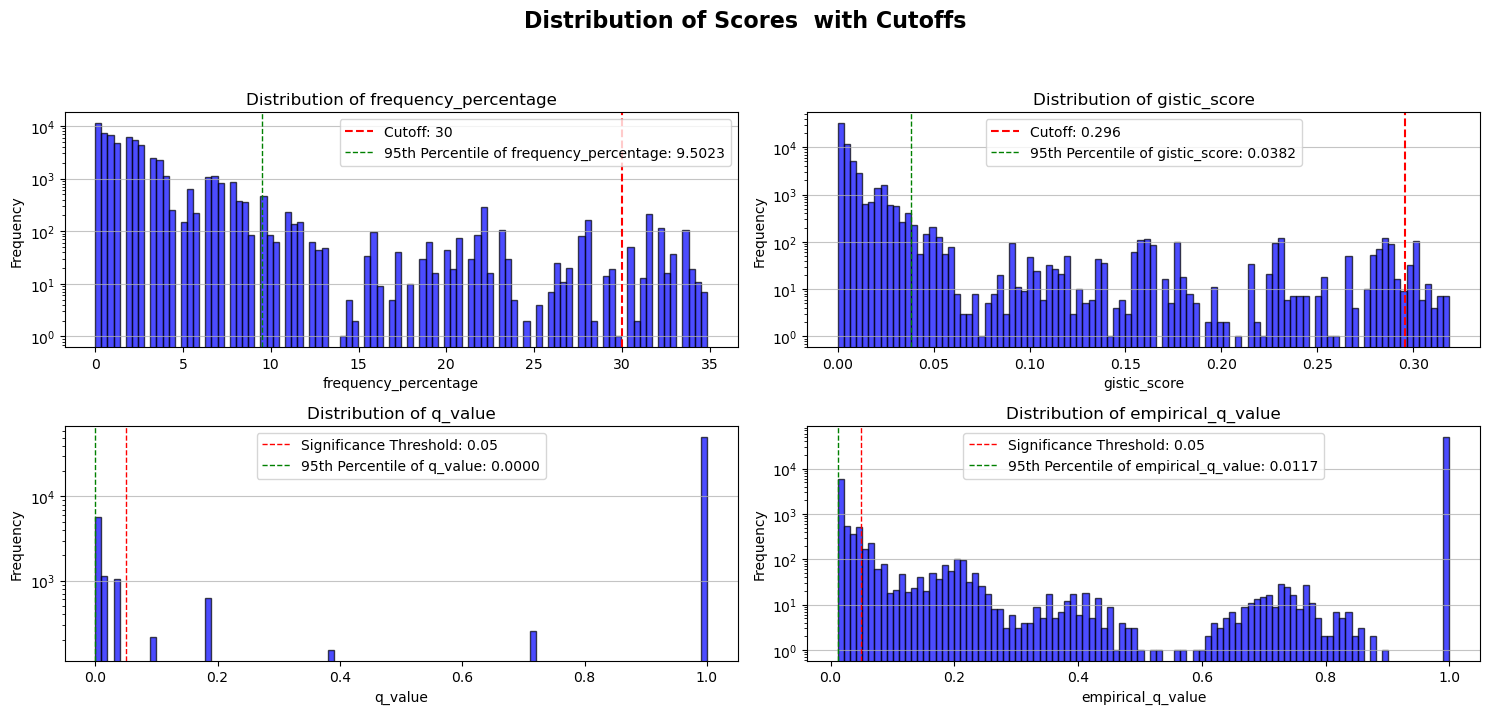

In [83]:
plot_score_distribution_with_cutoff(hpv_positive_amplification_gene_df, cutoffs)

In [84]:
hpv_positive_amplification_top_gene_df = hpv_positive_amplification_gene_df[
    (hpv_positive_amplification_gene_df['frequency_percentage'] >= cutoffs['frequency_percentage']) &
    (hpv_positive_amplification_gene_df['gistic_score'] >= cutoffs['gistic_score']) &
    (hpv_positive_amplification_gene_df['q_value'] <= cutoffs['q_value']) &
    (hpv_positive_amplification_gene_df['empirical_q_value'] <= cutoffs['empirical_q_value'])
].copy()

In [85]:
hpv_positive_amplification_top_gene_df

,gene,gene_name,Sample_size,amplification_count,Amplification_sum (i.e. total log2(amplification CNV) across samples),Amplification_sum_prevalence,frequency_percentage,gistic_score,p_value,q_value,significant,empirical_p_value,empirical_q_value,empirical_significant
0,ENSG00000252257.1,RN7SKP265,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
1,ENSG00000266317.2,RN7SL703P,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
2,ENSG00000199839.1,RNA5SP150,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
3,ENSG00000242512.9,LINC01206,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
4,ENSG00000240478.1,AC012081.1,221,77,202.286944,0.915326,34.841629,0.318914,2.137209e-60,1.850915e-56,True,0.000999,0.01166,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,ENSG00000244302.2,PEX5L-AS2,221,73,198.794490,0.899523,33.031674,0.297127,1.967884e-55,6.591105e-53,True,0.000999,0.01166,True
177,ENSG00000214147.2,AC092952.1,221,73,199.033176,0.900603,33.031674,0.297484,1.967884e-55,6.591105e-53,True,0.000999,0.01166,True
178,ENSG00000196083.10,IL1RAP,221,73,199.033176,0.900603,33.031674,0.297484,1.967884e-55,6.591105e-53,True,0.000999,0.01166,True
179,ENSG00000205835.9,GMNC,221,73,199.033176,0.900603,33.031674,0.297484,1.967884e-55,6.591105e-53,True,0.000999,0.01166,True


In [86]:
hpv_positive_amplification_top_gene_df.to_csv('Results/CNV results/HPV positive amplification top genes.csv', index=False)

#### Del

In [87]:
hpv_positive_deletion_gene_df

,gene,gene_name,Sample_size,deletion_count,Deletion_sum (i.e. total deletion CNV count across samples),Deletion_sum_prevalence,frequency_percentage,gistic_score,p_value,q_value,significant,empirical_p_value,empirical_q_value,empirical_significant
0,ENSG00000186312.10,CA5BP1,221,33,-140,0.633484,14.932127,0.094593,1.457958e-34,8.234937e-31,True,0.000999,0.020337,True
1,ENSG00000169239.13,CA5B,221,33,-140,0.633484,14.932127,0.094593,1.457958e-34,8.234937e-31,True,0.000999,0.020337,True
2,ENSG00000275800.1,EIF5P2,221,33,-140,0.633484,14.932127,0.094593,1.457958e-34,8.234937e-31,True,0.000999,0.020337,True
3,ENSG00000200620.1,AC112497.1,221,33,-140,0.633484,14.932127,0.094593,1.457958e-34,8.234937e-31,True,0.000999,0.020337,True
4,ENSG00000279413.1,AC112497.2,221,33,-140,0.633484,14.932127,0.094593,1.457958e-34,8.234937e-31,True,0.000999,0.020337,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60618,ENSG00000236164.1,AL161618.1,221,0,-18,0.081448,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.000000,False
60619,ENSG00000279994.1,AC017037.4,221,0,-34,0.153846,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.000000,False
60620,ENSG00000270441.1,LAMB2P1,221,0,-74,0.334842,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.000000,False
60621,ENSG00000259252.1,AC026583.1,221,0,-16,0.072398,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.000000,False


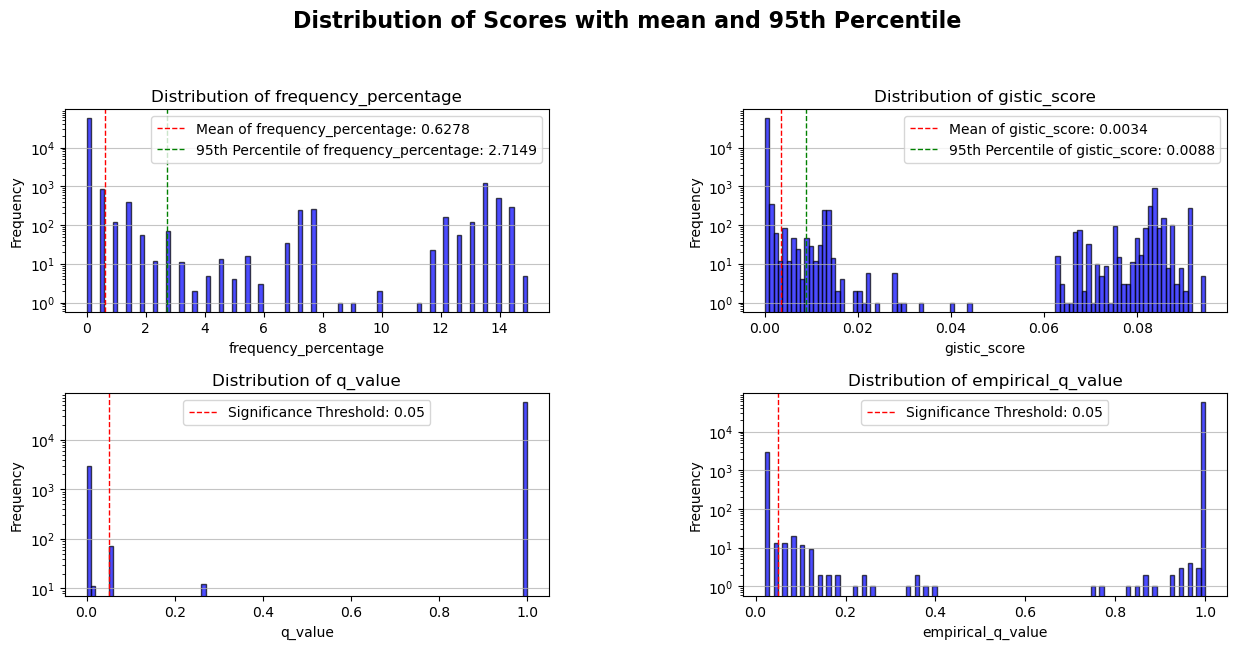

In [88]:
plot_score_distribution(hpv_positive_deletion_gene_df)

In [89]:
cutoffs = {
    'frequency_percentage': 12,
    'gistic_score': .091,
    'empirical_q_value': 0.05,
    'q_value': 0.05
}

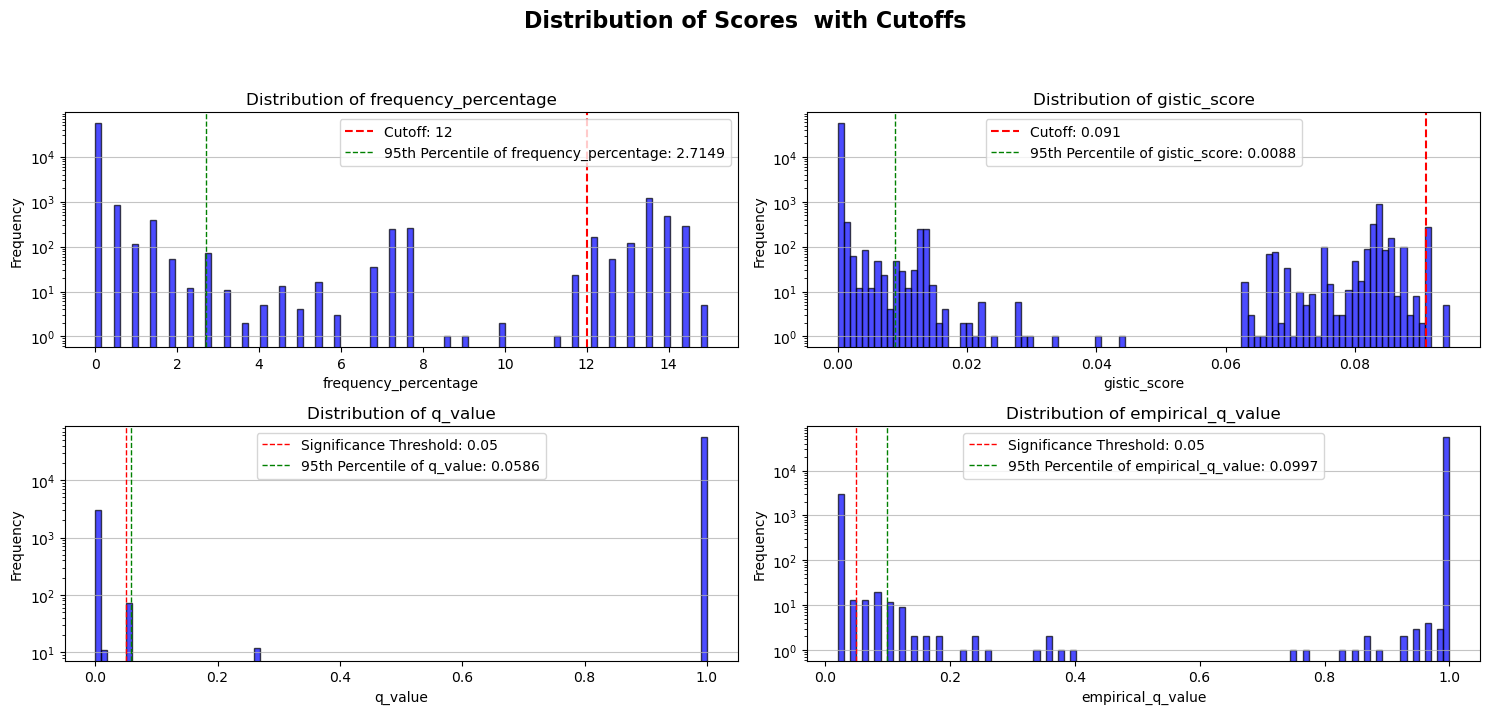

In [90]:
plot_score_distribution_with_cutoff(hpv_positive_deletion_gene_df, cutoffs)

In [91]:
### plot the gistic score distribution
plot_gistic_distribution(hpv_positive_deletion_gene_df, "GISTIC Score Distribution for HPV Positive Deletions")

In [92]:
hpv_positive_deletion_top_gene_df = hpv_positive_deletion_gene_df[
    (hpv_positive_deletion_gene_df['frequency_percentage'] >= cutoffs['frequency_percentage']) &
    (hpv_positive_deletion_gene_df['gistic_score'] >= cutoffs['gistic_score']) &
    (hpv_positive_deletion_gene_df['q_value'] <= cutoffs['q_value']) &
    (hpv_positive_deletion_gene_df['empirical_q_value'] <= cutoffs['empirical_q_value'])
].copy()

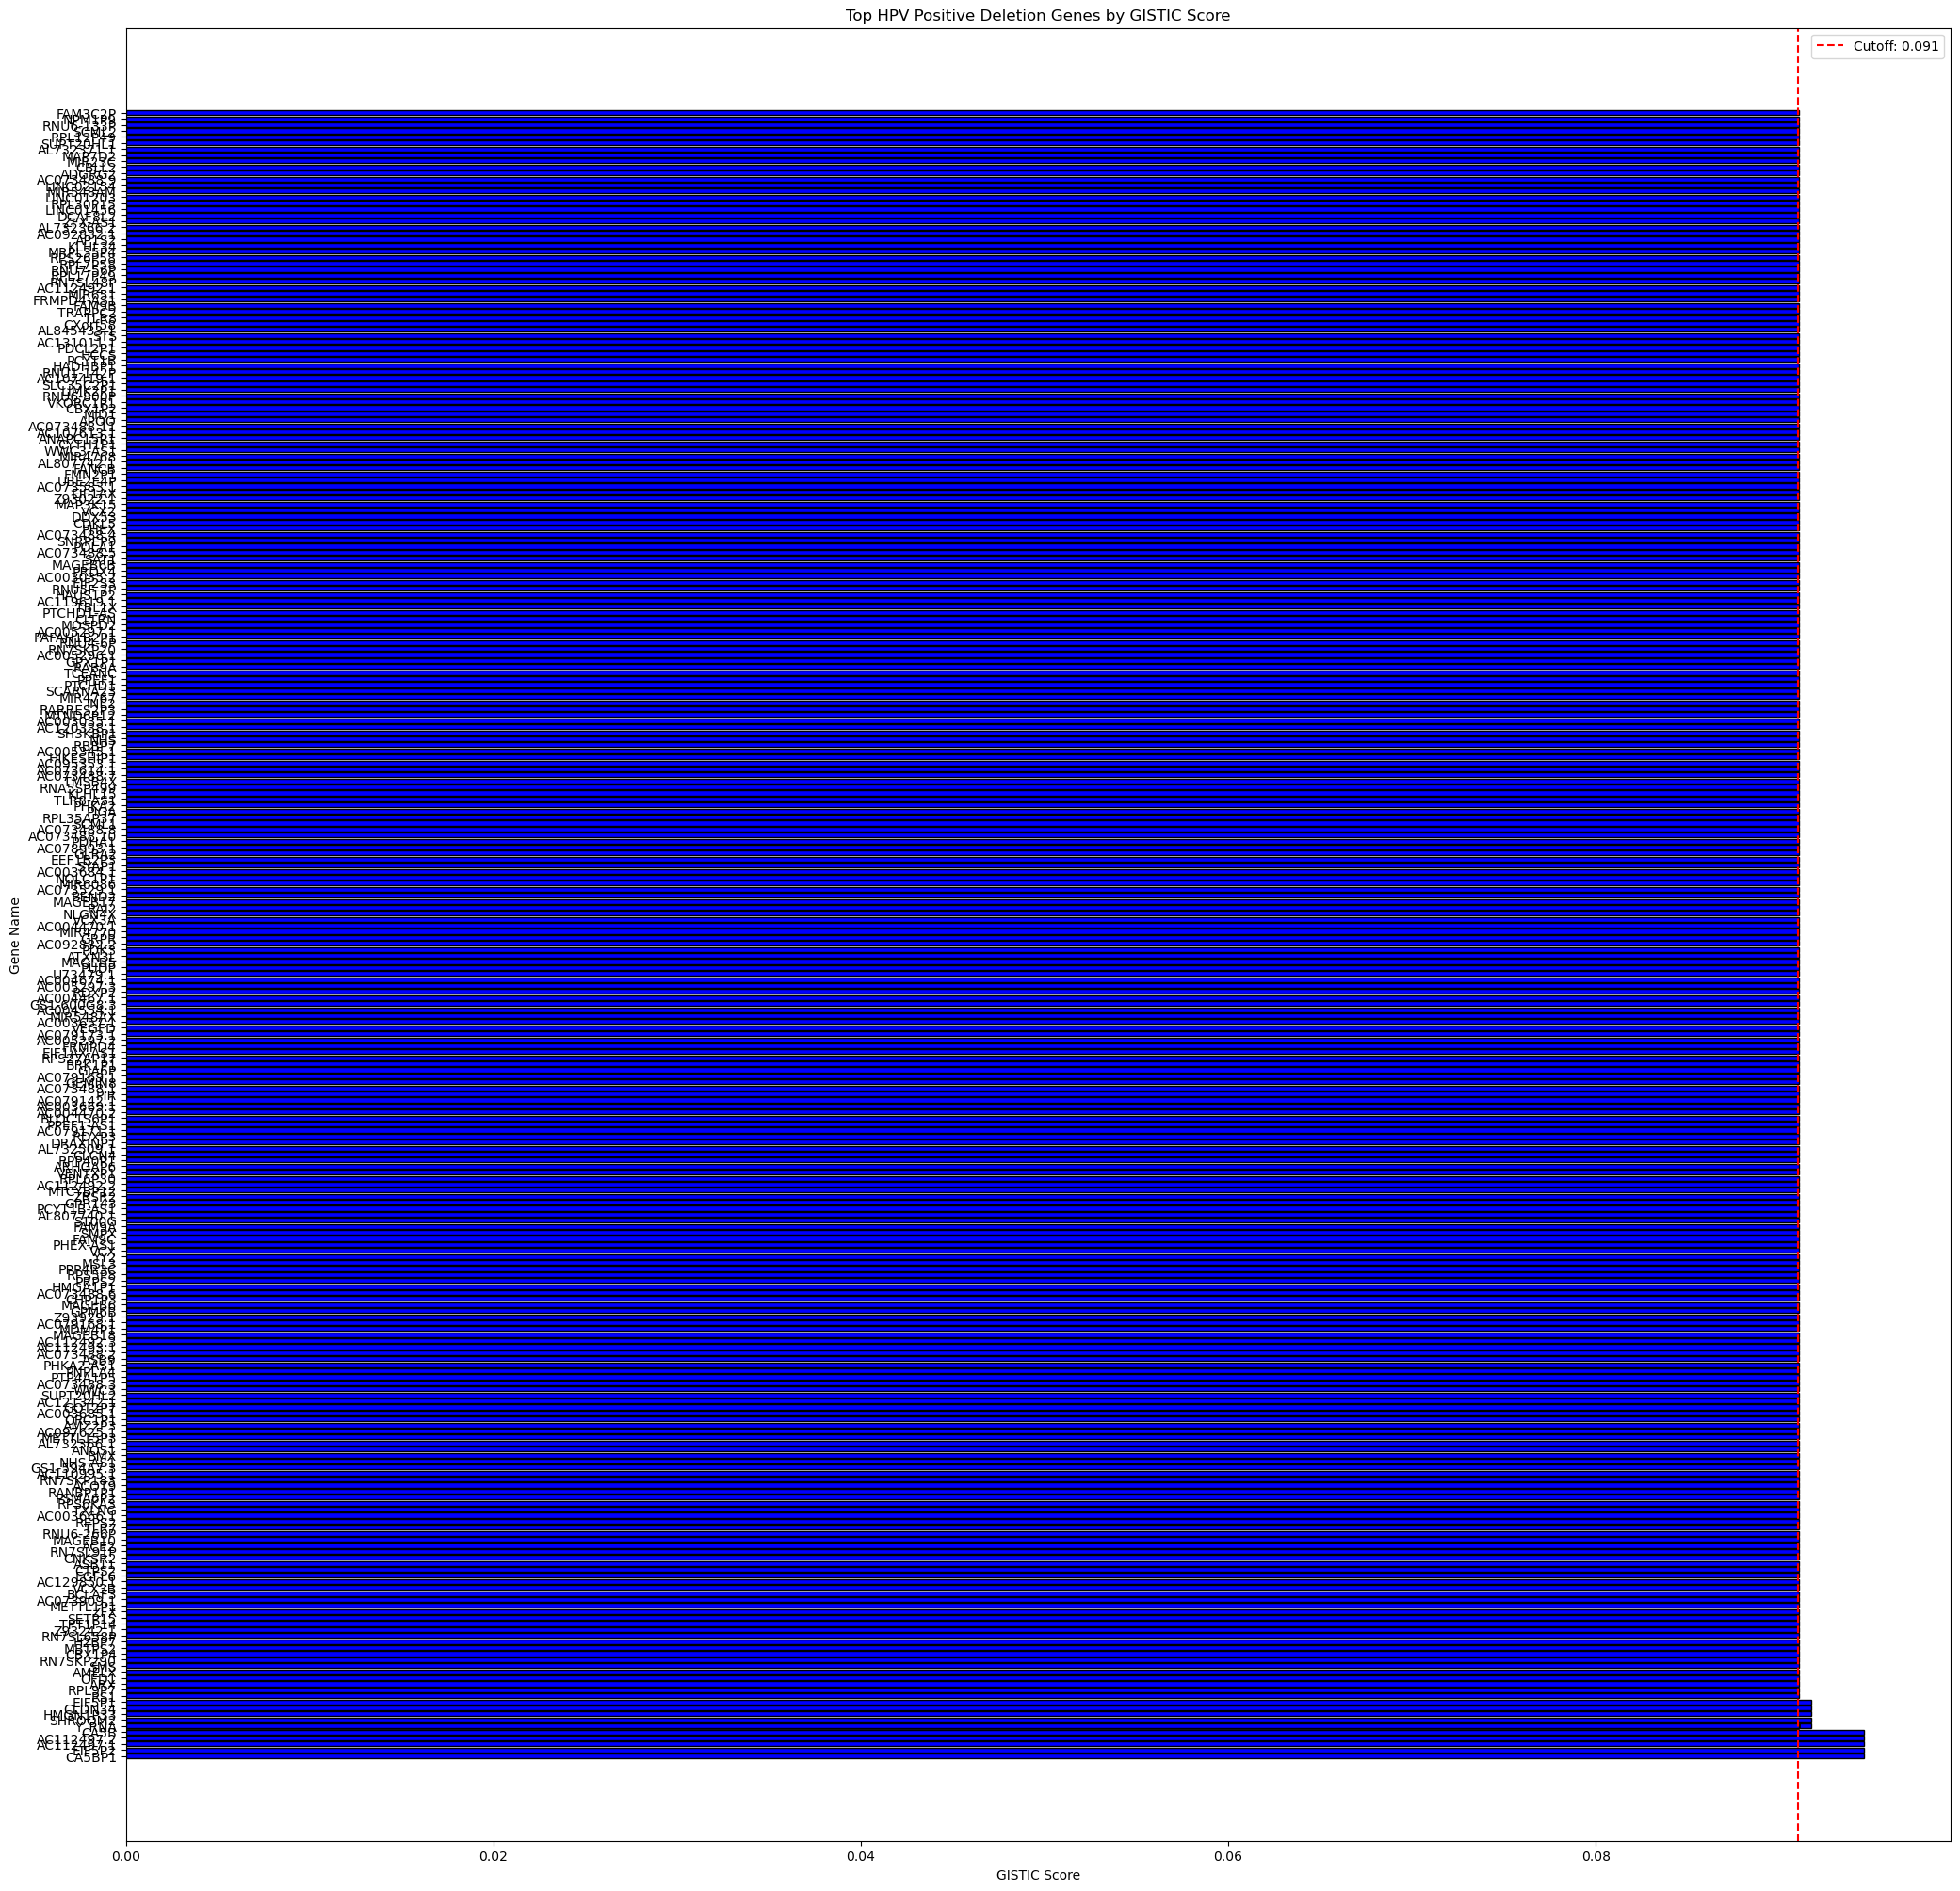

In [93]:
### plot gene vs gistic score
hpv_positive_deletion_top_gene_df.sort_values(by='gistic_score', ascending=False, inplace=True)
### make the plot larger to see all the genes
plt.figure(figsize=(25, 25))
plt.barh(hpv_positive_deletion_top_gene_df['gene_name'], hpv_positive_deletion_top_gene_df['gistic_score'], color='blue', edgecolor='black')
plt.axvline(x=cutoffs['gistic_score'], color='red', linestyle='--', label=f'Cutoff: {cutoffs["gistic_score"]}')
plt.title('Top HPV Positive Deletion Genes by GISTIC Score')
plt.xlabel('GISTIC Score')
plt.ylabel('Gene Name')
plt.legend()
plt.show()

In [94]:
hpv_positive_deletion_top_gene_df

,gene,gene_name,Sample_size,deletion_count,Deletion_sum (i.e. total deletion CNV count across samples),Deletion_sum_prevalence,frequency_percentage,gistic_score,p_value,q_value,significant,empirical_p_value,empirical_q_value,empirical_significant
0,ENSG00000186312.10,CA5BP1,221,33,-140,0.633484,14.932127,0.094593,1.457958e-34,8.234937e-31,True,0.000999,0.020337,True
2,ENSG00000275800.1,EIF5P2,221,33,-140,0.633484,14.932127,0.094593,1.457958e-34,8.234937e-31,True,0.000999,0.020337,True
3,ENSG00000200620.1,AC112497.1,221,33,-140,0.633484,14.932127,0.094593,1.457958e-34,8.234937e-31,True,0.000999,0.020337,True
4,ENSG00000279413.1,AC112497.2,221,33,-140,0.633484,14.932127,0.094593,1.457958e-34,8.234937e-31,True,0.000999,0.020337,True
1,ENSG00000169239.13,CA5B,221,33,-140,0.633484,14.932127,0.094593,1.457958e-34,8.234937e-31,True,0.000999,0.020337,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,ENSG00000230180.1,RPL12P49,221,32,-139,0.628959,14.479638,0.091071,4.034403e-33,8.234937e-31,True,0.000999,0.020337,True
108,ENSG00000102098.19,SCML2,221,32,-139,0.628959,14.479638,0.091071,4.034403e-33,8.234937e-31,True,0.000999,0.020337,True
109,ENSG00000206716.1,RNU6-133P,221,32,-139,0.628959,14.479638,0.091071,4.034403e-33,8.234937e-31,True,0.000999,0.020337,True
110,ENSG00000231066.3,NPM1P9,221,32,-139,0.628959,14.479638,0.091071,4.034403e-33,8.234937e-31,True,0.000999,0.020337,True


In [95]:
len(set(hpv_positive_deletion_top_gene_df['gene_name']))

274

In [96]:
hpv_positive_deletion_top_gene_df.to_csv('Results/CNV results/HPV positive deletion top genes.csv', index=False)

### HPV-

#### Amp

In [97]:
hpv_negative_amplification_gene_df

,gene,gene_name,Sample_size,amplification_count,Amplification_sum (i.e. total log2(amplification CNV) across samples),Amplification_sum_prevalence,frequency_percentage,gistic_score,p_value,q_value,significant,empirical_p_value,empirical_q_value,empirical_significant
0,ENSG00000230115.1,TPRG1-AS2,1327,488,1197.553464,0.902452,36.774680,0.331874,1.204131e-220,3.649901e-216,True,0.000999,0.004359,True
1,ENSG00000216058.1,MIR944,1327,488,1198.185824,0.902928,36.774680,0.332049,1.204131e-220,3.649901e-216,True,0.000999,0.004359,True
2,ENSG00000230077.1,MTAPP2,1327,482,1195.605330,0.900984,36.322532,0.327260,3.141842e-215,6.348930e-211,True,0.000999,0.004359,True
3,ENSG00000073282.14,TP63,1327,481,1187.242159,0.894681,36.247174,0.324297,2.483125e-214,3.010689e-210,True,0.000999,0.004359,True
4,ENSG00000238026.1,AC117434.1,1327,481,1179.467808,0.888823,36.247174,0.322173,2.483125e-214,3.010689e-210,True,0.000999,0.004359,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60618,ENSG00000283047.1,FRG1FP,1327,0,26.624063,0.020063,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.000000,False
60619,ENSG00000278903.3,CU633906.2,1327,0,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.000000,False
60620,ENSG00000286148.1,FP236383.10,1327,0,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.000000,False
60621,ENSG00000263305.1,AP005530.1,1327,0,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,False,1.000000,1.000000,False


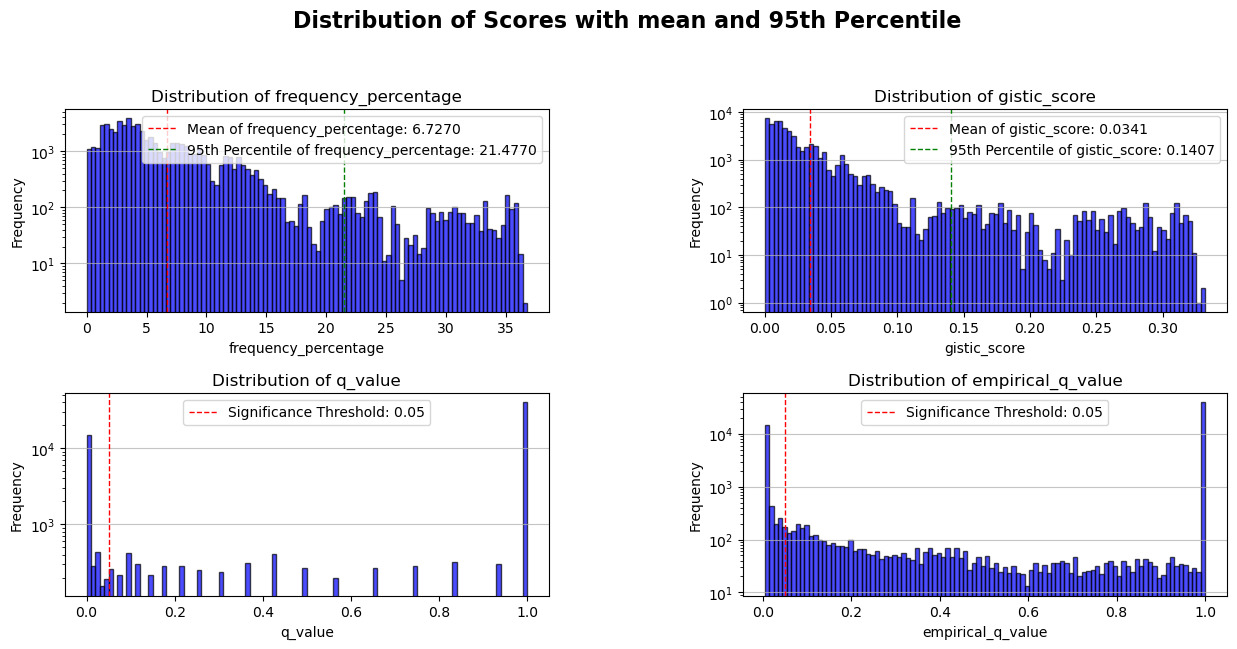

In [98]:
plot_score_distribution(hpv_negative_amplification_gene_df)

In [99]:
cutoffs = {
    'frequency_percentage': 34.5,
    'gistic_score': 0.3,
    'empirical_q_value': 0.05,
    'q_value': 0.05
}

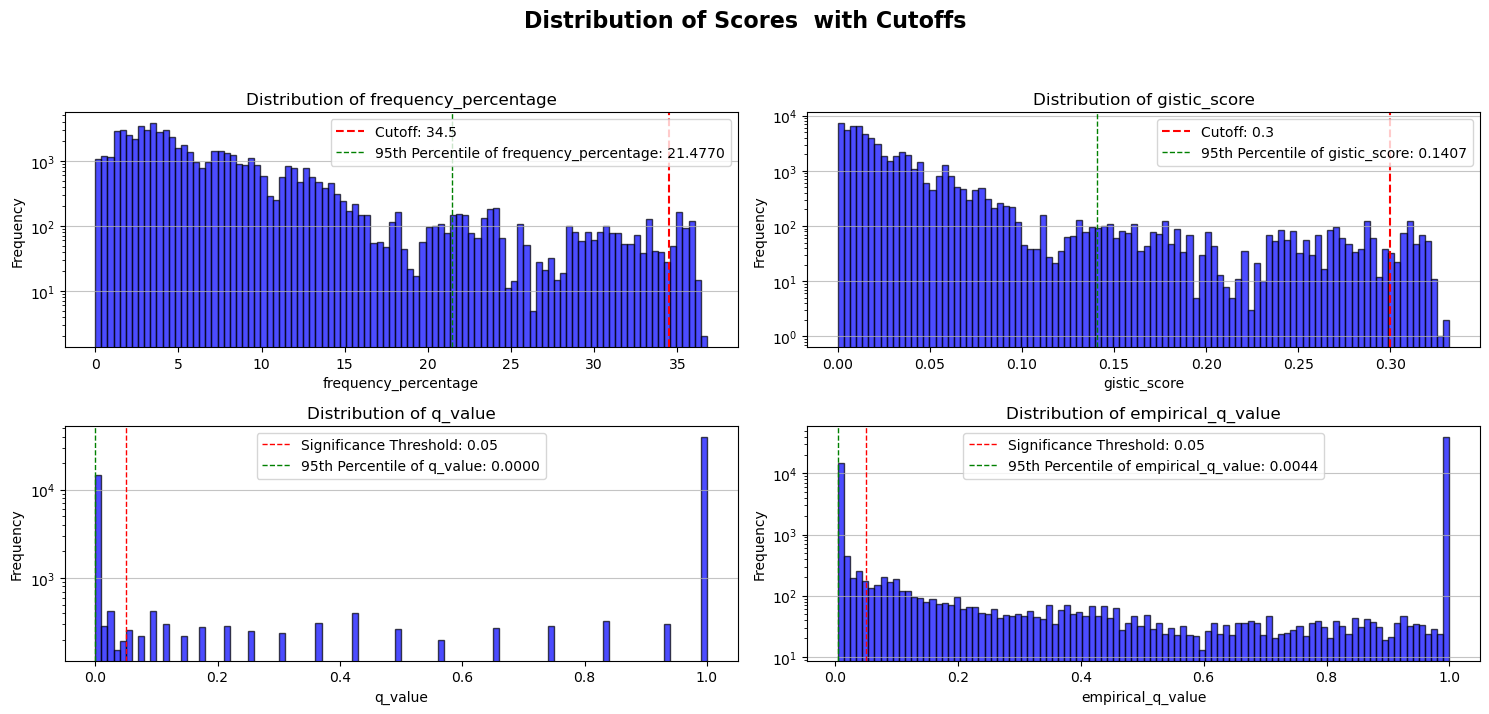

In [100]:
plot_score_distribution_with_cutoff(hpv_negative_amplification_gene_df, cutoffs)

In [101]:
hpv_negative_amplification_top_gene_df = hpv_negative_amplification_gene_df[
    (hpv_negative_amplification_gene_df['frequency_percentage'] >= cutoffs['frequency_percentage']) &
    (hpv_negative_amplification_gene_df['gistic_score'] >= cutoffs['gistic_score']) &
    (hpv_negative_amplification_gene_df['q_value'] <= cutoffs['q_value']) &
    (hpv_negative_amplification_gene_df['empirical_q_value'] <= cutoffs['empirical_q_value'])
].copy()

In [102]:
hpv_negative_amplification_top_gene_df

,gene,gene_name,Sample_size,amplification_count,Amplification_sum (i.e. total log2(amplification CNV) across samples),Amplification_sum_prevalence,frequency_percentage,gistic_score,p_value,q_value,significant,empirical_p_value,empirical_q_value,empirical_significant
0,ENSG00000230115.1,TPRG1-AS2,1327,488,1197.553464,0.902452,36.774680,0.331874,1.204131e-220,3.649901e-216,True,0.000999,0.004359,True
1,ENSG00000216058.1,MIR944,1327,488,1198.185824,0.902928,36.774680,0.332049,1.204131e-220,3.649901e-216,True,0.000999,0.004359,True
2,ENSG00000230077.1,MTAPP2,1327,482,1195.605330,0.900984,36.322532,0.327260,3.141842e-215,6.348930e-211,True,0.000999,0.004359,True
3,ENSG00000073282.14,TP63,1327,481,1187.242159,0.894681,36.247174,0.324297,2.483125e-214,3.010689e-210,True,0.000999,0.004359,True
4,ENSG00000238026.1,AC117434.1,1327,481,1179.467808,0.888823,36.247174,0.322173,2.483125e-214,3.010689e-210,True,0.000999,0.004359,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,ENSG00000196083.10,IL1RAP,1327,459,1164.184244,0.877305,34.589299,0.303454,6.121085e-195,8.376491e-193,True,0.000999,0.004359,True
429,ENSG00000224962.4,PSAT1P4,1327,459,1151.938860,0.868078,34.589299,0.300262,6.121085e-195,8.376491e-193,True,0.000999,0.004359,True
431,ENSG00000274149.1,AC072046.2,1327,459,1151.716468,0.867910,34.589299,0.300204,6.121085e-195,8.376491e-193,True,0.000999,0.004359,True
432,ENSG00000240458.1,AC072046.1,1327,459,1152.424287,0.868443,34.589299,0.300388,6.121085e-195,8.376491e-193,True,0.000999,0.004359,True


In [103]:
hpv_negative_amplification_top_gene_df.to_csv('Results/CNV results/HPV negative amplification top genes.csv', index=False)

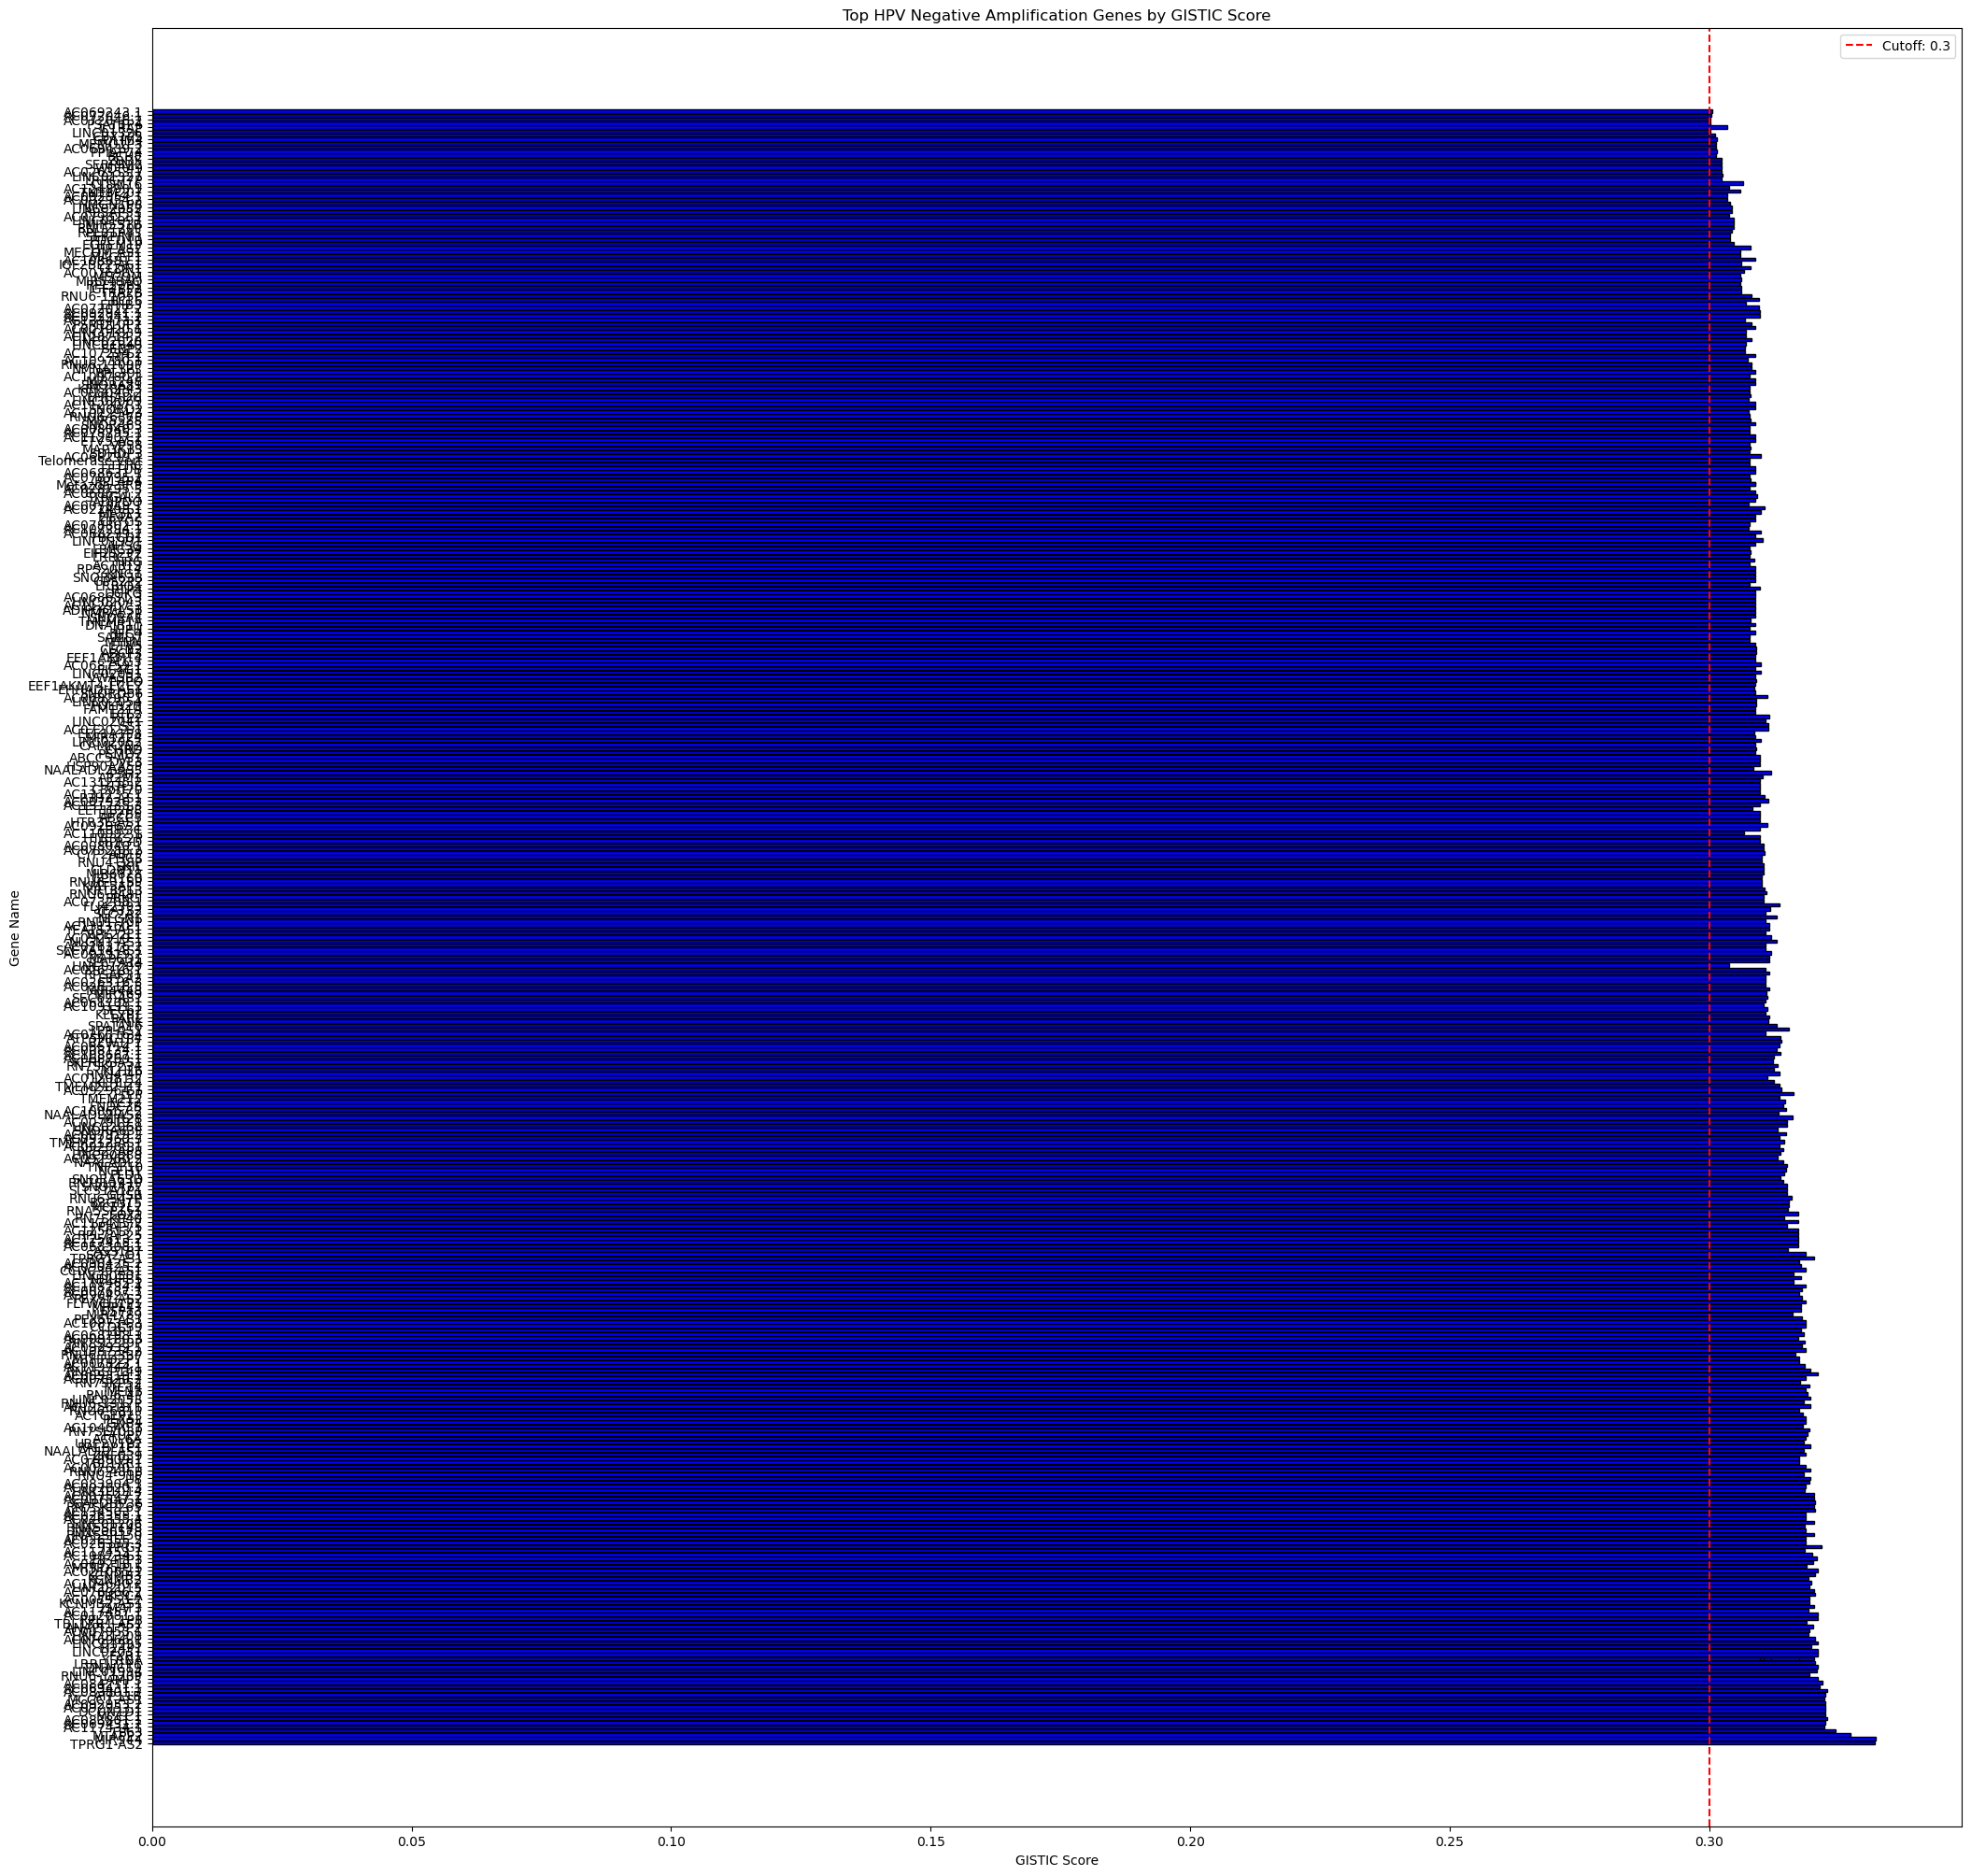

In [104]:
### plot gene vs gistic score
plt.figure(figsize=(25, 25))
plt.barh(hpv_negative_amplification_top_gene_df['gene_name'], hpv_negative_amplification_top_gene_df['gistic_score'], color='blue', edgecolor='black')
plt.axvline(x=cutoffs['gistic_score'], color='red', linestyle='--', label=f'Cutoff: {cutoffs["gistic_score"]}')
plt.title('Top HPV Negative Amplification Genes by GISTIC Score')
plt.xlabel('GISTIC Score')
plt.ylabel('Gene Name')
plt.legend()
plt.show()

In [105]:
hpv_neg_amp_genes = hpv_negative_amplification_top_gene_df['gene_name'].unique()
print(f"Number of unique genes in HPV negative amplification top genes: {len(hpv_neg_amp_genes)}")
drugbank_genes = list(set(Drug_bank['gene'].dropna().values))
overlap_genes = set(hpv_neg_amp_genes) & set(drugbank_genes)
print(f"Number of overlapping genes between HPV negative amplification top genes and DrugBank genes: {len(overlap_genes)}")
print(f"Overlapping genes: {overlap_genes}")

## immediate neighbors of these genes in the PPI network
hpv_neg_amp_genes = hpv_negative_amplification_top_gene_df['gene_name'].unique()
ppi_genes = list(set(protein_interaction['Translated_protein_1'].dropna().values) | set(protein_interaction['Translated_protein_2'].dropna().values))
overlap_genes = set(hpv_neg_amp_genes) & set(ppi_genes)
#print(f"Number of overlapping genes between HPV negative amplification top genes and PPI genes: {len(overlap_genes)}")
# print(f"Overlapping genes: {overlap_genes}")

## number of immediate neighbors of the top genes in the PPI network
usable_protein_interaction = protein_interaction[protein_interaction['combined_score'] > 700]
protein_interaction_neighbors = usable_protein_interaction[usable_protein_interaction['Translated_protein_1'].isin(overlap_genes)]
### remove duplicates and hpv neg amp genes from the neighbors
immediate_neighbors = protein_interaction_neighbors['Translated_protein_2'].unique()
print(f"Number of immediate neighbors of the top genes in the PPI network: {len(immediate_neighbors)}")

### number of immediate neighbors or key risk genes that are in drugbank
# This will give us a list of all the immediate neighbors and key risk genes that we want to check for overlap with drugbank
immediate_neighbors_and_risk = list(list(immediate_neighbors) + list(hpv_neg_amp_genes)) 
### this will give us the number of immediate neighbors or key risk genes that are in drugbank
immediate_neighbors_and_risk_in_drugbank = set(immediate_neighbors_and_risk) & set(drugbank_genes)
print(f"Number of immediate neighbors or key risk genes that are in DrugBank: {len(set(immediate_neighbors_and_risk_in_drugbank))}")
#print(f"Immediate neighbors or key risk genes that are in DrugBank: {immediate_neighbors_and_risk_in_drugbank}")

Number of unique genes in HPV negative amplification top genes: 408
Number of overlapping genes between HPV negative amplification top genes and DrugBank genes: 24
Overlapping genes: {'KCNMB2', 'NDUFB5', 'MAP3K13', 'ABCC5', 'PIK3CA', 'CLCN2', 'SLC2A2', 'TNIK', 'P3H2', 'BCHE', 'KNG1', 'EHHADH', 'PRKCI', 'HTR3E', 'AHSG', 'HRG', 'DGKG', 'TNFSF10', 'SST', 'MCCC1', 'HTR3D', 'PLD1', 'HTR3C', 'GHSR'}
Number of immediate neighbors of the top genes in the PPI network: 2912
Number of immediate neighbors or key risk genes that are in DrugBank: 867


#### Del

In [106]:
hpv_negative_deletion_gene_df

,gene,gene_name,Sample_size,deletion_count,Deletion_sum (i.e. total deletion CNV count across samples),Deletion_sum_prevalence,frequency_percentage,gistic_score,p_value,q_value,significant,empirical_p_value,empirical_q_value,empirical_significant
0,ENSG00000147889.18,CDKN2A,1327,330,-940,0.708365,24.868124,0.176157,0.0,0.0,True,0.000999,0.019171,True
1,ENSG00000266446.1,AL449423.1,1327,329,-938,0.706858,24.792766,0.175250,0.0,0.0,True,0.000999,0.019171,True
2,ENSG00000147883.12,CDKN2B,1327,322,-925,0.697061,24.265260,0.169144,0.0,0.0,True,0.000999,0.019171,True
3,ENSG00000215221.2,UBA52P6,1327,311,-903,0.680482,23.436323,0.159480,0.0,0.0,True,0.000999,0.019171,True
4,ENSG00000224854.3,CDKN2A-DT,1327,295,-861,0.648832,22.230595,0.144239,0.0,0.0,True,0.000999,0.019171,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60618,ENSG00000265401.1,AC093484.3,1327,0,-123,0.092690,0.000000,0.000000,1.0,1.0,False,1.000000,1.000000,False
60619,ENSG00000201221.1,RNU4-40P,1327,0,-20,0.015072,0.000000,0.000000,1.0,1.0,False,1.000000,1.000000,False
60620,ENSG00000233476.3,EEF1A1P6,1327,0,-19,0.014318,0.000000,0.000000,1.0,1.0,False,1.000000,1.000000,False
60621,ENSG00000169507.9,SLC38A11,1327,0,-17,0.012811,0.000000,0.000000,1.0,1.0,False,1.000000,1.000000,False


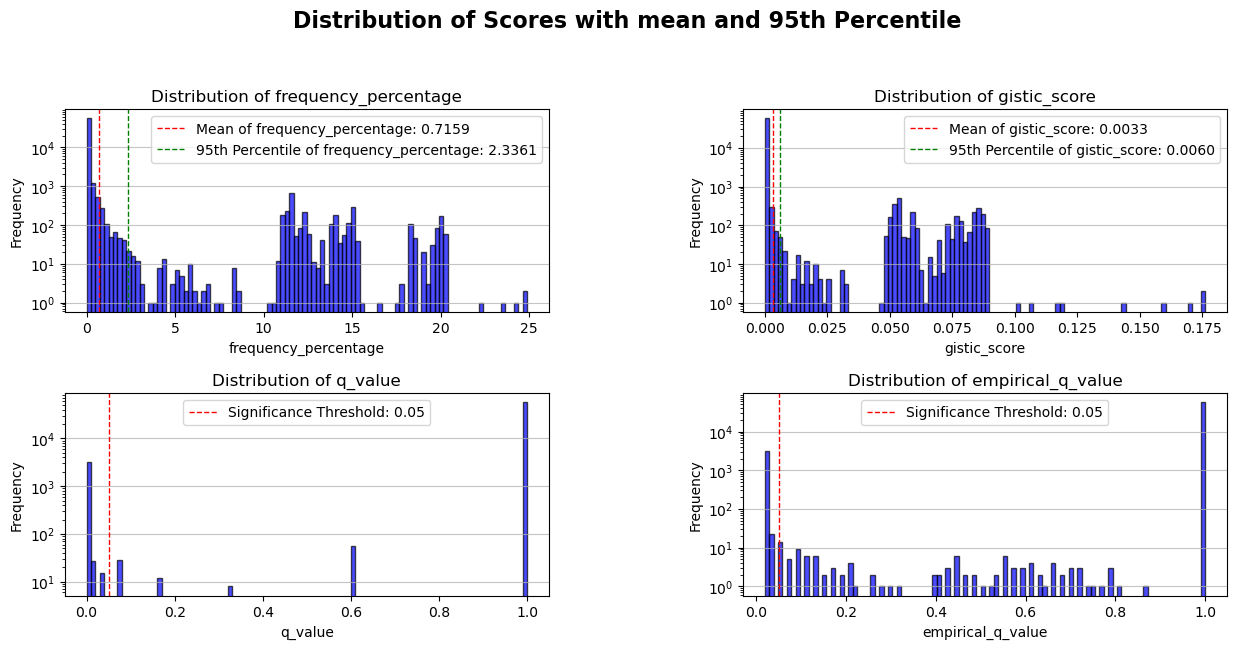

In [107]:
plot_score_distribution(hpv_negative_deletion_gene_df)

In [108]:
cutoffs = {
    'frequency_percentage': 19,
    'gistic_score': .0845,
    'empirical_q_value': 0.05,
    'q_value': 0.05
}

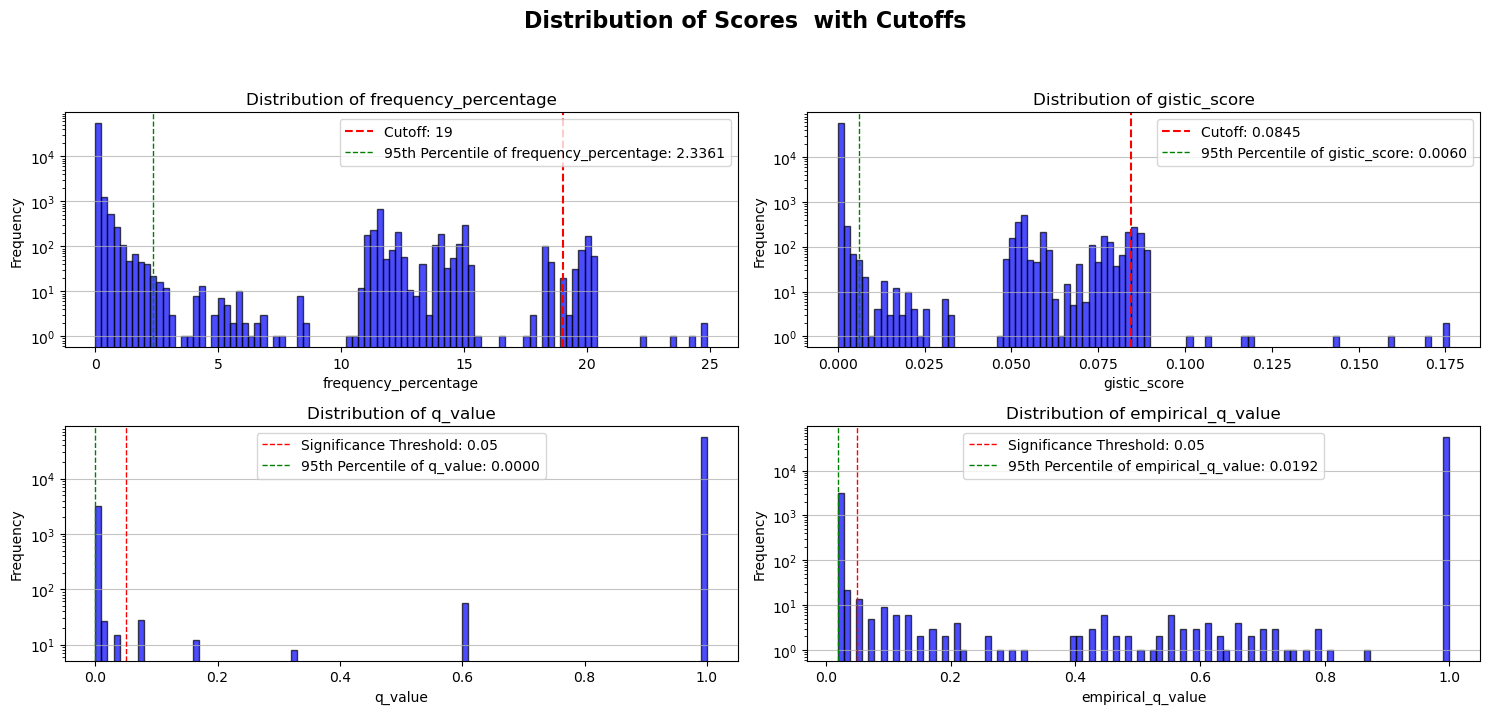

In [109]:
plot_score_distribution_with_cutoff(hpv_negative_deletion_gene_df, cutoffs)

In [110]:
hpv_negative_deletion_top_gene_df = hpv_negative_deletion_gene_df[
    (hpv_negative_deletion_gene_df['frequency_percentage'] >= cutoffs['frequency_percentage']) &
    (hpv_negative_deletion_gene_df['gistic_score'] >= cutoffs['gistic_score']) &
    (hpv_negative_deletion_gene_df['q_value'] <= cutoffs['q_value']) &
    (hpv_negative_deletion_gene_df['empirical_q_value'] <= cutoffs['empirical_q_value'])
].copy()

In [111]:
hpv_negative_deletion_top_gene_df

,gene,gene_name,Sample_size,deletion_count,Deletion_sum (i.e. total deletion CNV count across samples),Deletion_sum_prevalence,frequency_percentage,gistic_score,p_value,q_value,significant,empirical_p_value,empirical_q_value,empirical_significant
0,ENSG00000147889.18,CDKN2A,1327,330,-940,0.708365,24.868124,0.176157,0.000000e+00,0.000000e+00,True,0.000999,0.019171,True
1,ENSG00000266446.1,AL449423.1,1327,329,-938,0.706858,24.792766,0.175250,0.000000e+00,0.000000e+00,True,0.000999,0.019171,True
2,ENSG00000147883.12,CDKN2B,1327,322,-925,0.697061,24.265260,0.169144,0.000000e+00,0.000000e+00,True,0.000999,0.019171,True
3,ENSG00000215221.2,UBA52P6,1327,311,-903,0.680482,23.436323,0.159480,0.000000e+00,0.000000e+00,True,0.000999,0.019171,True
4,ENSG00000224854.3,CDKN2A-DT,1327,295,-861,0.648832,22.230595,0.144239,0.000000e+00,0.000000e+00,True,0.000999,0.019171,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,ENSG00000237558.1,CDY7P,1327,262,-571,0.430294,19.743783,0.084956,2.650161e-281,5.005007e-279,True,0.000999,0.019171,True
318,ENSG00000227494.2,USP9YP14,1327,262,-571,0.430294,19.743783,0.084956,2.650161e-281,5.005007e-279,True,0.000999,0.019171,True
319,ENSG00000226555.1,AGKP1,1327,262,-570,0.429540,19.743783,0.084808,2.650161e-281,5.005007e-279,True,0.000999,0.019171,True
320,ENSG00000252513.1,RNU1-128P,1327,262,-571,0.430294,19.743783,0.084956,2.650161e-281,5.005007e-279,True,0.000999,0.019171,True


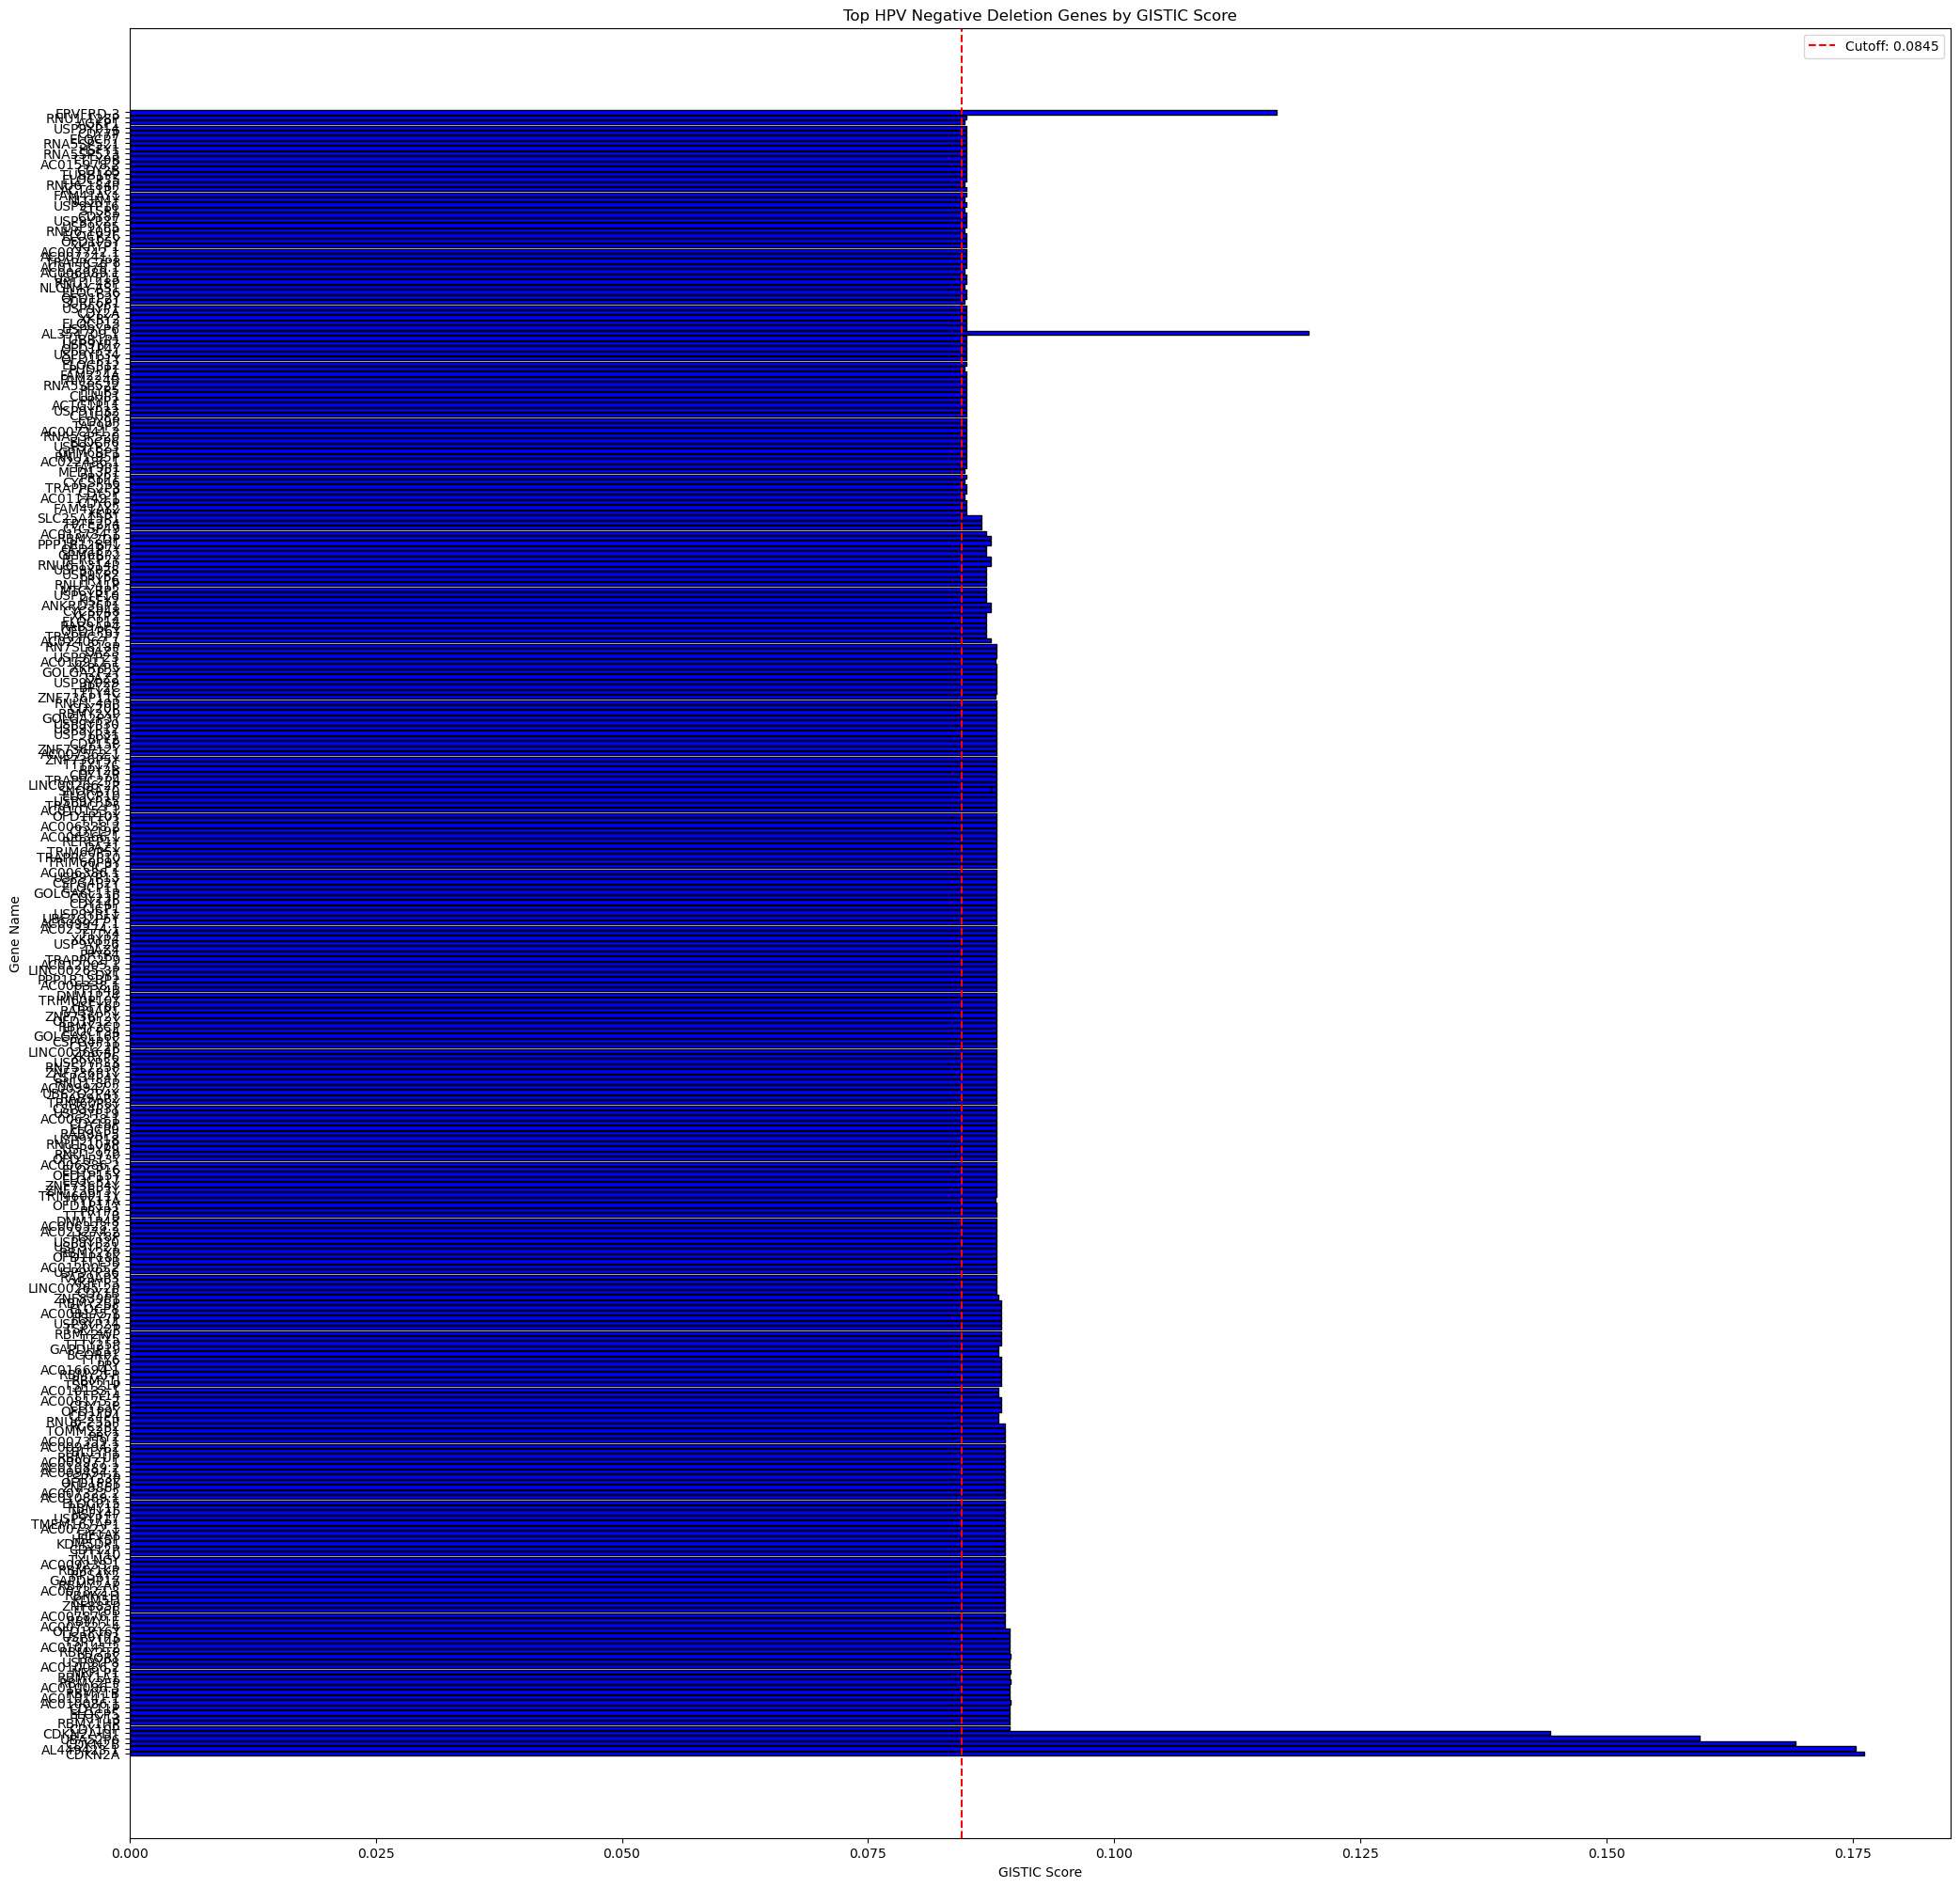

In [112]:
### plot gene vs gistic scores
plt.figure(figsize=(25, 25))
plt.barh(hpv_negative_deletion_top_gene_df['gene_name'], hpv_negative_deletion_top_gene_df['gistic_score'], color='blue', edgecolor='black')
plt.axvline(x=cutoffs['gistic_score'], color='red', linestyle='--', label=f'Cutoff: {cutoffs["gistic_score"]}')
plt.title('Top HPV Negative Deletion Genes by GISTIC Score')
plt.xlabel('GISTIC Score')
plt.ylabel('Gene Name')
plt.legend()
plt.show()

In [113]:
hpv_neg_del_genes = hpv_negative_deletion_top_gene_df['gene_name'].unique()
print(f"Number of unique genes in HPV negative deletion top genes: {len(hpv_neg_del_genes)}")
drugbank_genes = list(set(Drug_bank['gene'].dropna().values))
overlap_genes = set(hpv_neg_del_genes) & set(drugbank_genes)
print(f"Number of overlapping genes between HPV negative deletion top genes and DrugBank genes: {len(overlap_genes)}")
print(f"Overlapping genes: {overlap_genes}")

## immediate neighbors of these genes in the PPI network
hpv_neg_del_genes = hpv_negative_deletion_top_gene_df['gene_name'].unique()
ppi_genes = list(set(protein_interaction['Translated_protein_1'].dropna().values) | set(protein_interaction['Translated_protein_2'].dropna().values))
overlap_genes = set(hpv_neg_del_genes) & set(ppi_genes)
#print(f"Number of overlapping genes between HPV negative deletion top genes and PPI genes: {len(overlap_genes)}")
# print(f"Overlapping genes: {overlap_genes}")

## number of immediate neighbors of the top genes in the PPI network
usable_protein_interaction = protein_interaction[protein_interaction['combined_score'] > 700]
protein_interaction_neighbors = usable_protein_interaction[usable_protein_interaction['Translated_protein_1'].isin(overlap_genes)]
### remove duplicates and hpv neg del genes from the neighbors
immediate_neighbors = protein_interaction_neighbors['Translated_protein_2'].unique()
print(f"Number of immediate neighbors of the top genes in the PPI network: {len(immediate_neighbors)}")

### number of immediate neighbors or key risk genes that are in drugbank
# This will give us a list of all the immediate neighbors and key risk genes that we want to check for overlap with drugbank
immediate_neighbors_and_risk = list(list(immediate_neighbors) + list(hpv_neg_del_genes)) 
immediate_neighbors_and_risk_in_drugbank = set(immediate_neighbors_and_risk) & set(drugbank_genes)
print(f"Number of immediate neighbors or key risk genes that are in DrugBank: {len(immediate_neighbors_and_risk_in_drugbank)}")
print(f"Immediate neighbors or key risk genes that are in DrugBank: {immediate_neighbors_and_risk_in_drugbank}")

Number of unique genes in HPV negative deletion top genes: 321
Number of overlapping genes between HPV negative deletion top genes and DrugBank genes: 1
Overlapping genes: {'KDM5D'}
Number of immediate neighbors of the top genes in the PPI network: 460
Number of immediate neighbors or key risk genes that are in DrugBank: 127
Immediate neighbors or key risk genes that are in DrugBank: {'MAPK1', 'EZH2', 'PRIM1', 'NPM1', 'TOP1', 'HNRNPK', 'DLG4', 'PDGFRA', 'UCHL1', 'RPL14', 'CASK', 'NRAS', 'ATM', 'CHEK1', 'CDK1', 'RPS28', 'SP1', 'EFL1', 'RIOK1', 'RPL10', 'RPS18', 'RPS6', 'TUFM', 'RPL18', 'NRXN1', 'ARF1', 'C1QBP', 'FGFR3', 'FHIT', 'NFE2L2', 'ACTR2', 'RPL19', 'AR', 'RIOK2', 'CEBPB', 'RPL13A', 'MC1R', 'CDK6', 'CHEK2', 'MT-ATP6', 'RPS2', 'CDK5', 'RPL11', 'RPSA', 'SNU13', 'CDKN1A', 'DNMT3B', 'AURKB', 'MED1', 'BRAF', 'RPS9', 'RPL3', 'KRAS', 'CDK4', 'SRC', 'ERBB2', 'KDM5D', 'MGMT', 'ATP5F1A', 'PIK3CA', 'ABL1', 'BBOX1', 'RPL10L', 'ATP5F1D', 'DNMT1', 'HIF1A', 'TP53', 'ARL3', 'RACK1', 'RPL35', 'TPT

In [114]:
hpv_negative_deletion_top_gene_df.to_csv('Results/CNV results/HPV negative deletion top genes.csv', index=False)

In [115]:
top_hpv_negative_deletion_genes = list(hpv_negative_deletion_top_gene_df['gene_name'].values)

In [116]:
# Drug_bank[Drug_bank['gene'].isin(top_hpv_negative_deletion_genes)]